# Importation

In [2]:
# LES ALGORITHMES
# Pour StableBaselines
from QLearning import *
from DQN import *
from PPO import *
from helperPlot import *

# Pour RLLib
import ray
from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from ray import train, tune
from rllib_helper import *

# Aide
import time
from pprint import pprint

# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

# Environnements

Ce premier labyrinthe ne donne qu'une unique récompense en cas de sortie de l'agent du labyrinthe.

In [3]:
class FrozenLakeEnv(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLakeEnv, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.width * self.height)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        return self.state, {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = 0
        else :
            reward = 0
        return self.state, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x
    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

Le second environnement ajoute les récompenses négatives à chaque pas et à chaque fois que l'agent tombe dans un trou.

In [4]:
class FrozenLake2Env(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLake2Env, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Discrete(self.width * self.height)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        return self.state, {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = -1
        else :
            reward = -1/(self.width * self.height)
        return self.state, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x
    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

Dans le troisième environnement, l'agent perçoit les cases adjacentes à sa position.

In [5]:
class FrozenLake3Env(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLake3Env, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.cell_values = {'F' : 0, 'S' : 0, 'H' : 1, 'G' : 2, 'W' : 3}
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.MultiDiscrete([self.width * self.height, 4, 4, 4, 4])
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        

    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break


        left, down, right, up = self._getNeighbors(self.state)
        return np.array([self.state, left, down, right, up]), {}
    
    def step(self, action) :
        x, y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if x > 0 :
                x -= 1
        elif action == 1 : # Down
            if y < self.height -1 :
                y += 1
        elif action == 2 : # Right
            if x < self.width -1 :
                x += 1
        elif action == 3 : # Up
            if y > 0 :
                y -= 1
        
        self.state = self._coordinateToState(x, y)
        
        result = self.map[y][x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = -1
        else :
            reward = -1/(self.width * self.height)

        left, down, right, up = self._getNeighbors(self.state)
        return np.array([self.state, left, down, right, up]), reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x

    def _getNeighbors(self, state) :
        x, y = self._stateToCoordinate(state)
        if x == 0 :  # Retrieve left cell
            left = self.cell_values['W']
        else :
            left = self.cell_values[self.map[y][x-1]]

        if y == self.height -1 :  # Retrieve down cell
            down = self.cell_values["W"]
        else :
            down = self.cell_values[self.map[y+1][x]]

        if x == self.width -1 :   # Retrieve right cell
            right = self.cell_values["W"]
        else :
            right = self.cell_values[self.map[y][x+1]]

        if y == 0 :   # Retrieve up cell
            up = self.cell_values["W"]
        else :
            up = self.cell_values[self.map[y-1][x]]

        return left, down, right, up


    
    def render(self) :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

Dans ce quatrième épisode, la position est codée par deux neurones qui envoient les coordonnées de l'agent.

In [6]:
class FrozenLake4Env(gymnasium.Env) :
    def __init__(self, options = None) :
        super(FrozenLake4Env, self).__init__()
        self.map = options['lake_map']
        self.width = len(self.map[0])
        self.height = len(self.map)
        self.cell_values = {'F' : 0, 'S' : 0, 'H' : 1, 'G' : 2, 'W' : 3}
        self.action_space = spaces.Discrete(4)
        self.observation_space = spaces.Dict({
            'row_position' : spaces.Box(low = 0, high = self.width - 1, dtype = int),
            'col_position' : spaces.Box(low = 0, high = self.height - 1, dtype = int),
            'left_neighbor' : spaces.Discrete(4),
            'down_neighbor' : spaces.Discrete(4),
            'right_neighbor' : spaces.Discrete(4),
            'up_neighbor' : spaces.Discrete(4)
        })
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    break
        

    
    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)
        self.state = 0

        for x in range(self.width) :
            for y in range(self.height) :
                if self.map[y][x] == 'S' :
                    self.state = self._coordinateToState(x, y)
                    self.x = x
                    self.y = y
                    break


        left, down, right, up = self._getNeighbors(self.state)
        toReturn = {
            'row_position' : np.array([self.x]),
            'col_position' : np.array([self.y]),
            'left_neighbor' : left,
            'down_neighbor' : down,
            'right_neighbor' : right,
            'up_neighbor' : up
        }
        return toReturn, {}
    
    def step(self, action) :
        self.x, self.y = self._stateToCoordinate(self.state)
        if action == 0 : # Left
            if self.x > 0 :
                self.x -= 1
        elif action == 1 : # Down
            if self.y < self.height -1 :
                self.y += 1
        elif action == 2 : # Right
            if self.x < self.width -1 :
                self.x += 1
        elif action == 3 : # Up
            if self.y > 0 :
                self.y -= 1
        
        self.state = self._coordinateToState(self.x, self.y)
        
        result = self.map[self.y][self.x]
        done = result in ['H', 'G']
        if result == 'G' :
            reward = 1
        elif result == 'H' :
            reward = -1
        else :
            reward = -1/(self.width * self.height)

        left, down, right, up = self._getNeighbors(self.state)
        toReturn = {
            'row_position' : np.array([self.x]),
            'col_position' : np.array([self.y]),
            'left_neighbor' : left,
            'down_neighbor' : down,
            'right_neighbor' : right,
            'up_neighbor' : up
        }
        return toReturn, reward, done, False, {}
    
    
    def _stateToCoordinate(self, state) :
        x = state % self.width
        y = state // self.width
        return x, y
    
    def _coordinateToState(self, x, y) :
        return self.width*y + x

    def _getNeighbors(self, state) :
        x, y = self._stateToCoordinate(state)
        if x == 0 :  # Retrieve left cell
            left = self.cell_values['W']
        else :
            left = self.cell_values[self.map[y][x-1]]

        if y == self.height -1 :  # Retrieve down cell
            down = self.cell_values["W"]
        else :
            down = self.cell_values[self.map[y+1][x]]

        if x == self.width -1 :   # Retrieve right cell
            right = self.cell_values["W"]
        else :
            right = self.cell_values[self.map[y][x+1]]

        if y == 0 :   # Retrieve up cell
            up = self.cell_values["W"]
        else :
            up = self.cell_values[self.map[y-1][x]]

        return left, down, right, up


    
    def render(self, mode = 'human') :
        x, y = self._stateToCoordinate(self.state)
        toPrint = ''
        for i in range(self.height) :
            toPrintRow = ''
            row = self.map[i]
            for j in range(self.width) :
                if (j, i) == (x, y):
                    toPrintRow += '.'
                else :
                    toPrintRow += row[j]
            toPrint += toPrintRow + '\n'
        print(toPrint)

# Entraînement du DQN de RLlib sur labyrinthe env 1

In [15]:
config = (
    DQNConfig()
    .environment(
        FrozenLakeEnv,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [35000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[16], [32], [64], [16, 16], [32, 32]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-18 21:49:14,300	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/thewalder/ray_results/DQN_2025-06-18_21-14-16' in 0.3517s.
2025-06-18 21:49:14,352	INFO tune.py:1041 -- Total run time: 2098.25 seconds (2097.84 seconds for the tuning loop).


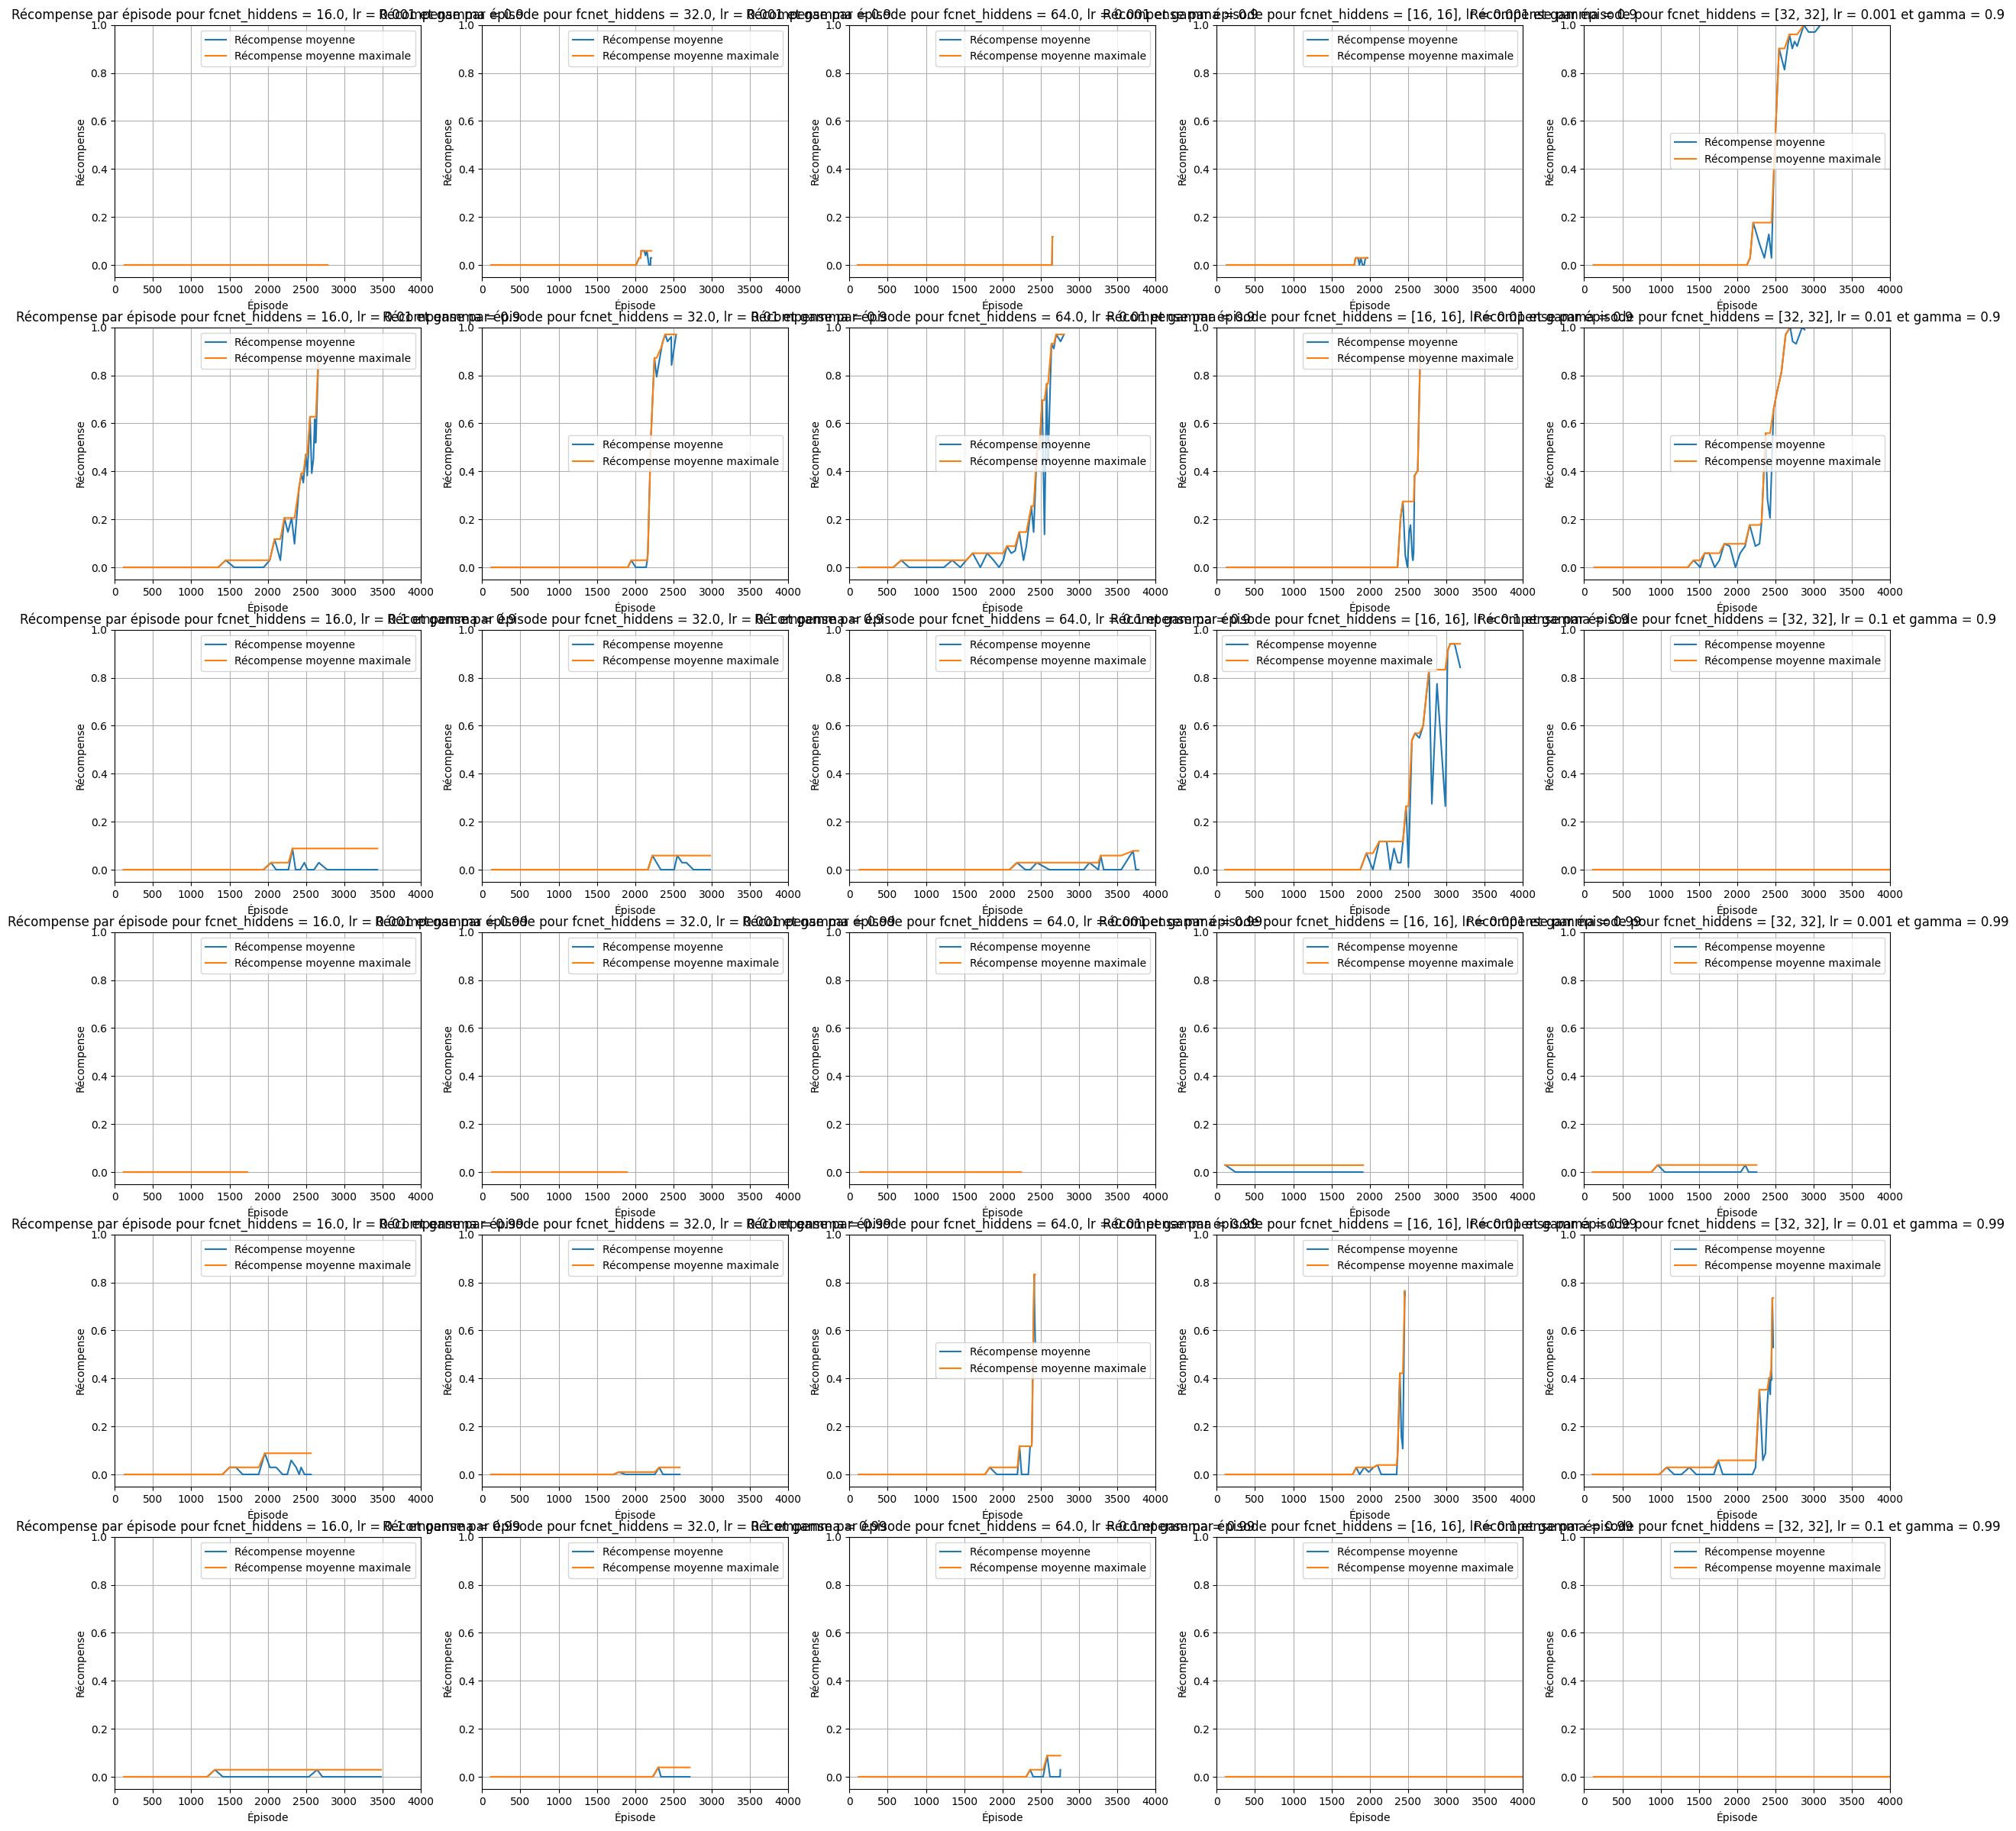

In [16]:
comparison_plot_3(results,
                  "fcnet_hiddens", [16., 32., 64., [16, 16], [32, 32]],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -0.05, 1
                 )

Meilleurs résultats obtenus pour :

- Architecture : [32, 32]
- lr = 0.01
- gamma = 0.9

# DQN pour environnement 2

In [13]:
config = (
    DQNConfig()
    .environment(
        FrozenLake2Env,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [35000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[8], [32], [128], [16, 16], [64, 64]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-18 21:00:30,007	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/thewalder/ray_results/DQN_2025-06-18_20-24-25' in 0.5154s.
2025-06-18 21:00:30,045	INFO tune.py:1041 -- Total run time: 2164.34 seconds (2163.77 seconds for the tuning loop).


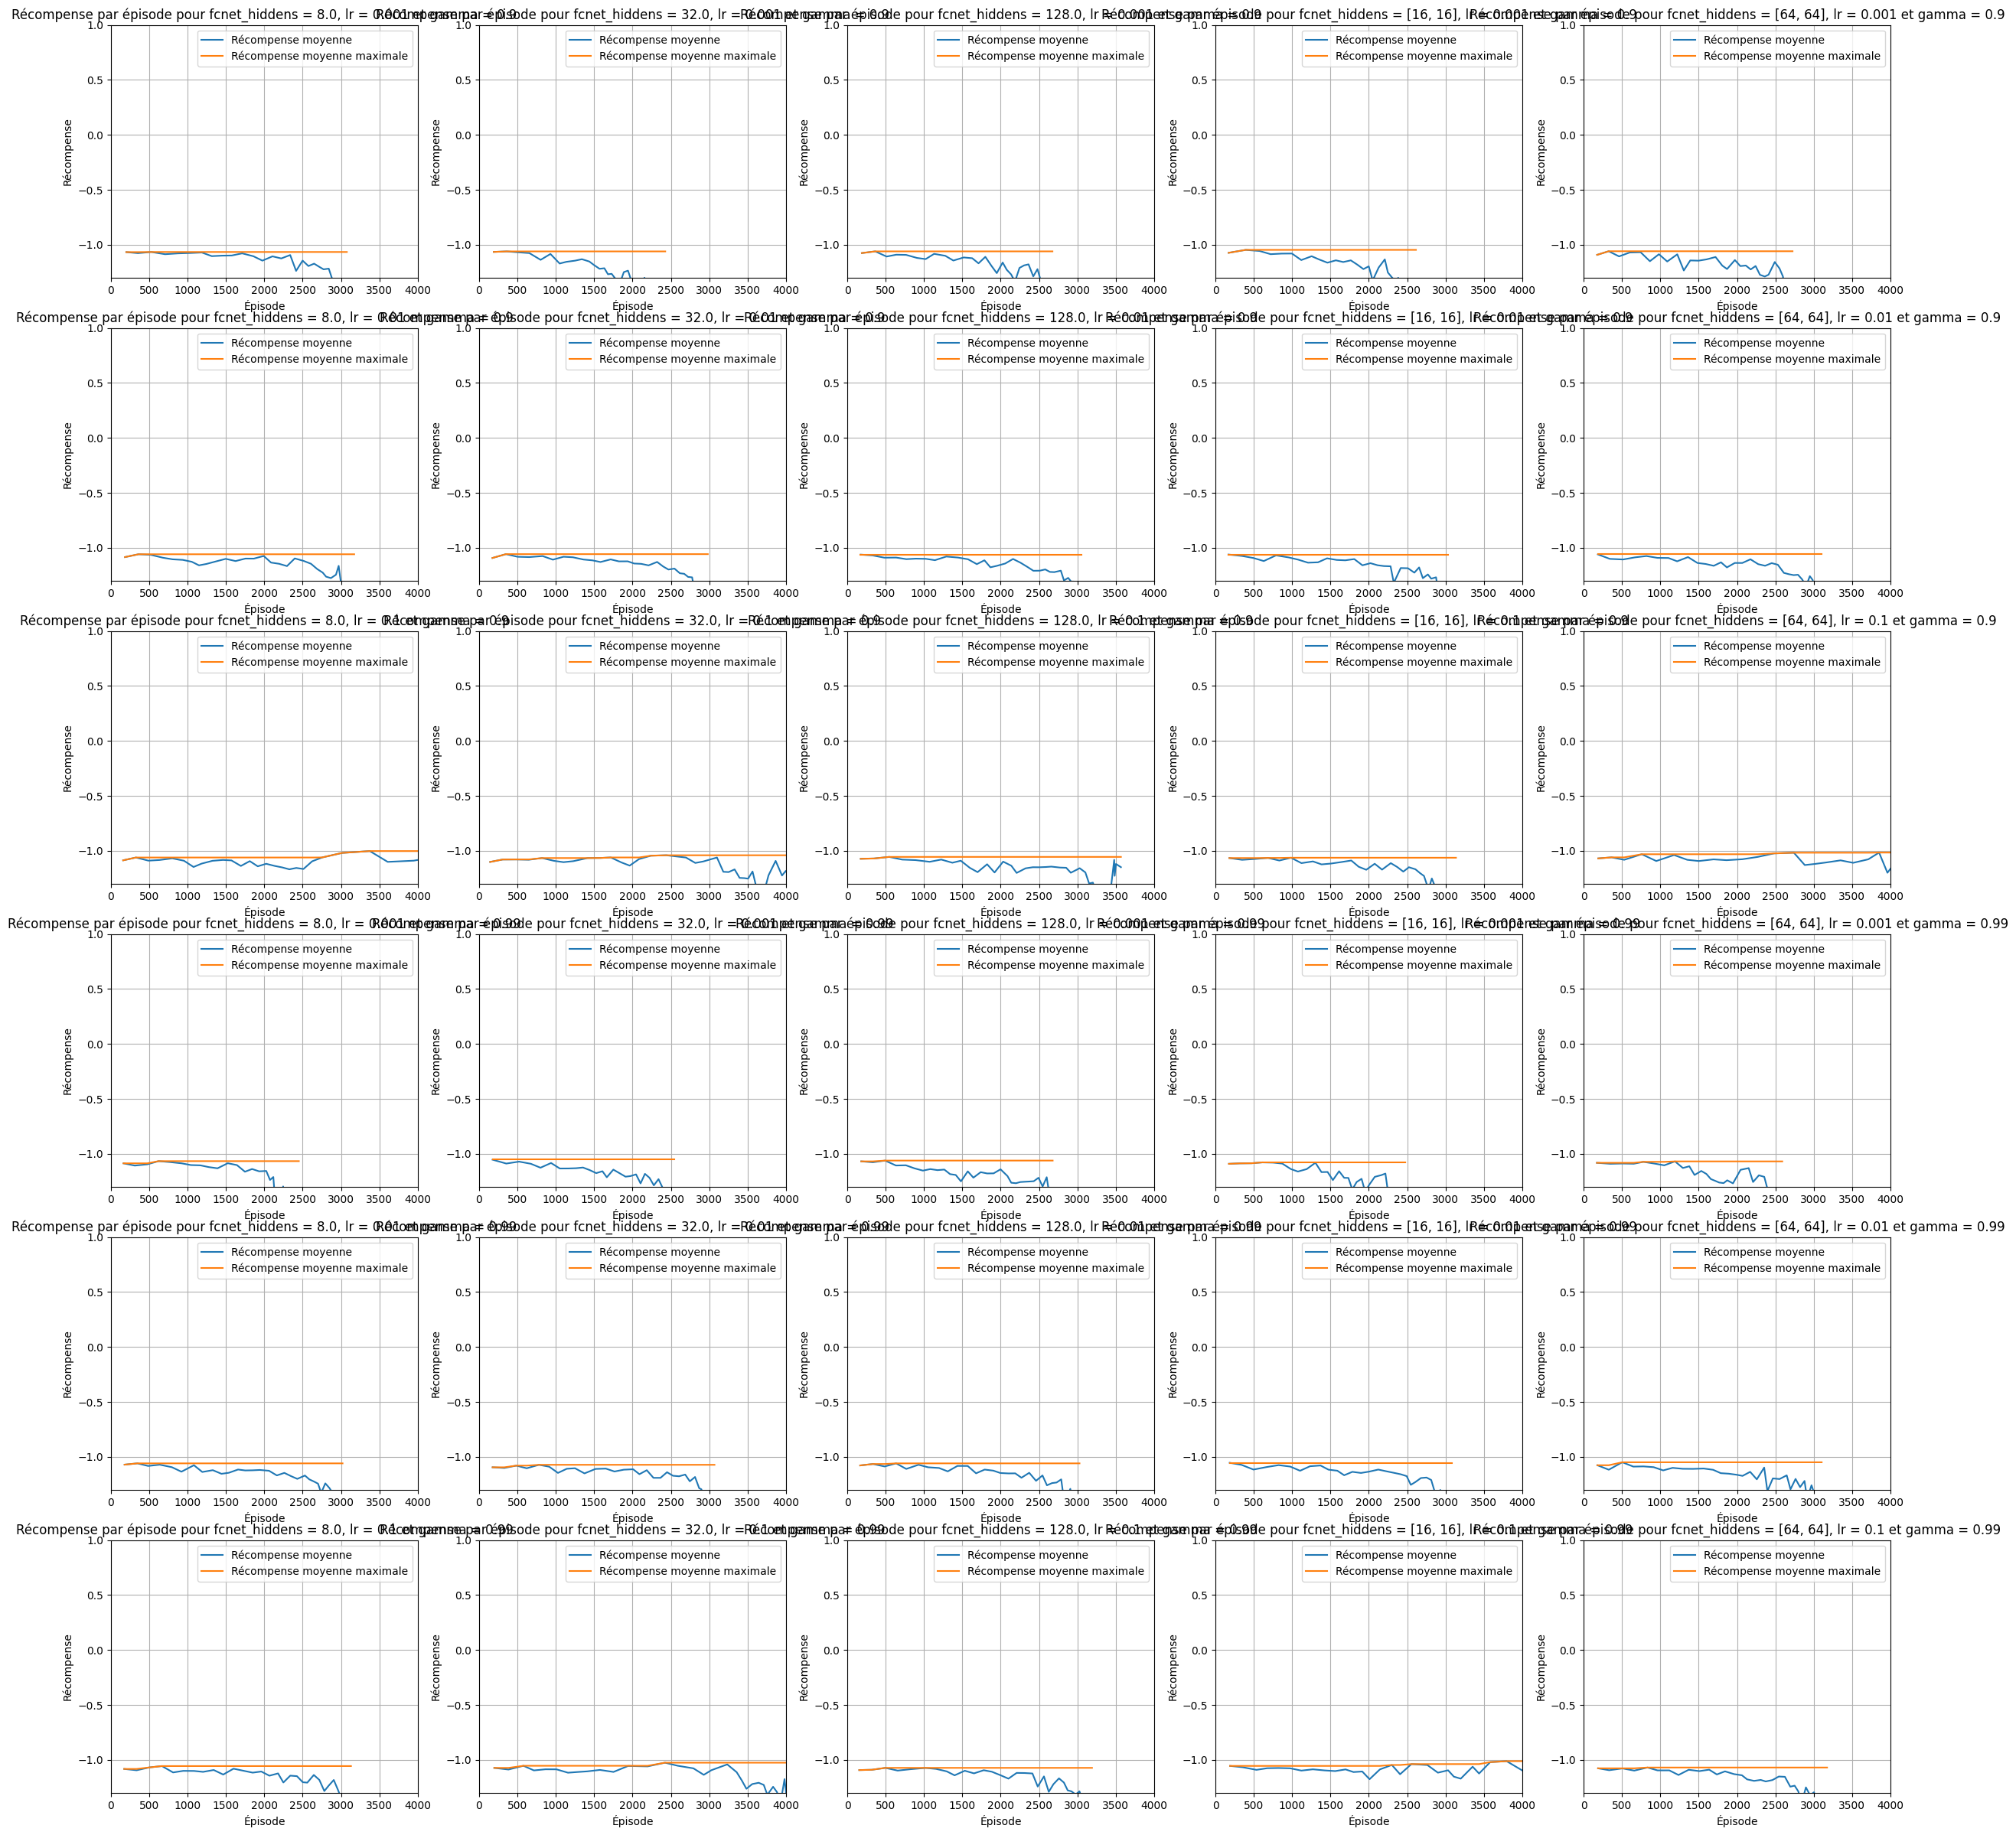

In [14]:
comparison_plot_3(results,
                  "fcnet_hiddens", [8., 32., 128., [16, 16], [64, 64]],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 4000,
                  -1.3, 1
                 )

Nous avons toujours de très mauvais résultats

# DQN pour environnement 3

In [10]:
config = (
    DQNConfig()
    .environment(
        FrozenLake3Env,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = tune.grid_search([0.0001, 0.001, 0.01]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [35000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[16], [32], [64], [16, 16], [32, 32]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-18 20:21:05,365	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/thewalder/ray_results/DQN_2025-06-18_19-43-18' in 0.4011s.
2025-06-18 20:21:05,591	INFO tune.py:1041 -- Total run time: 2266.70 seconds (2266.06 seconds for the tuning loop).


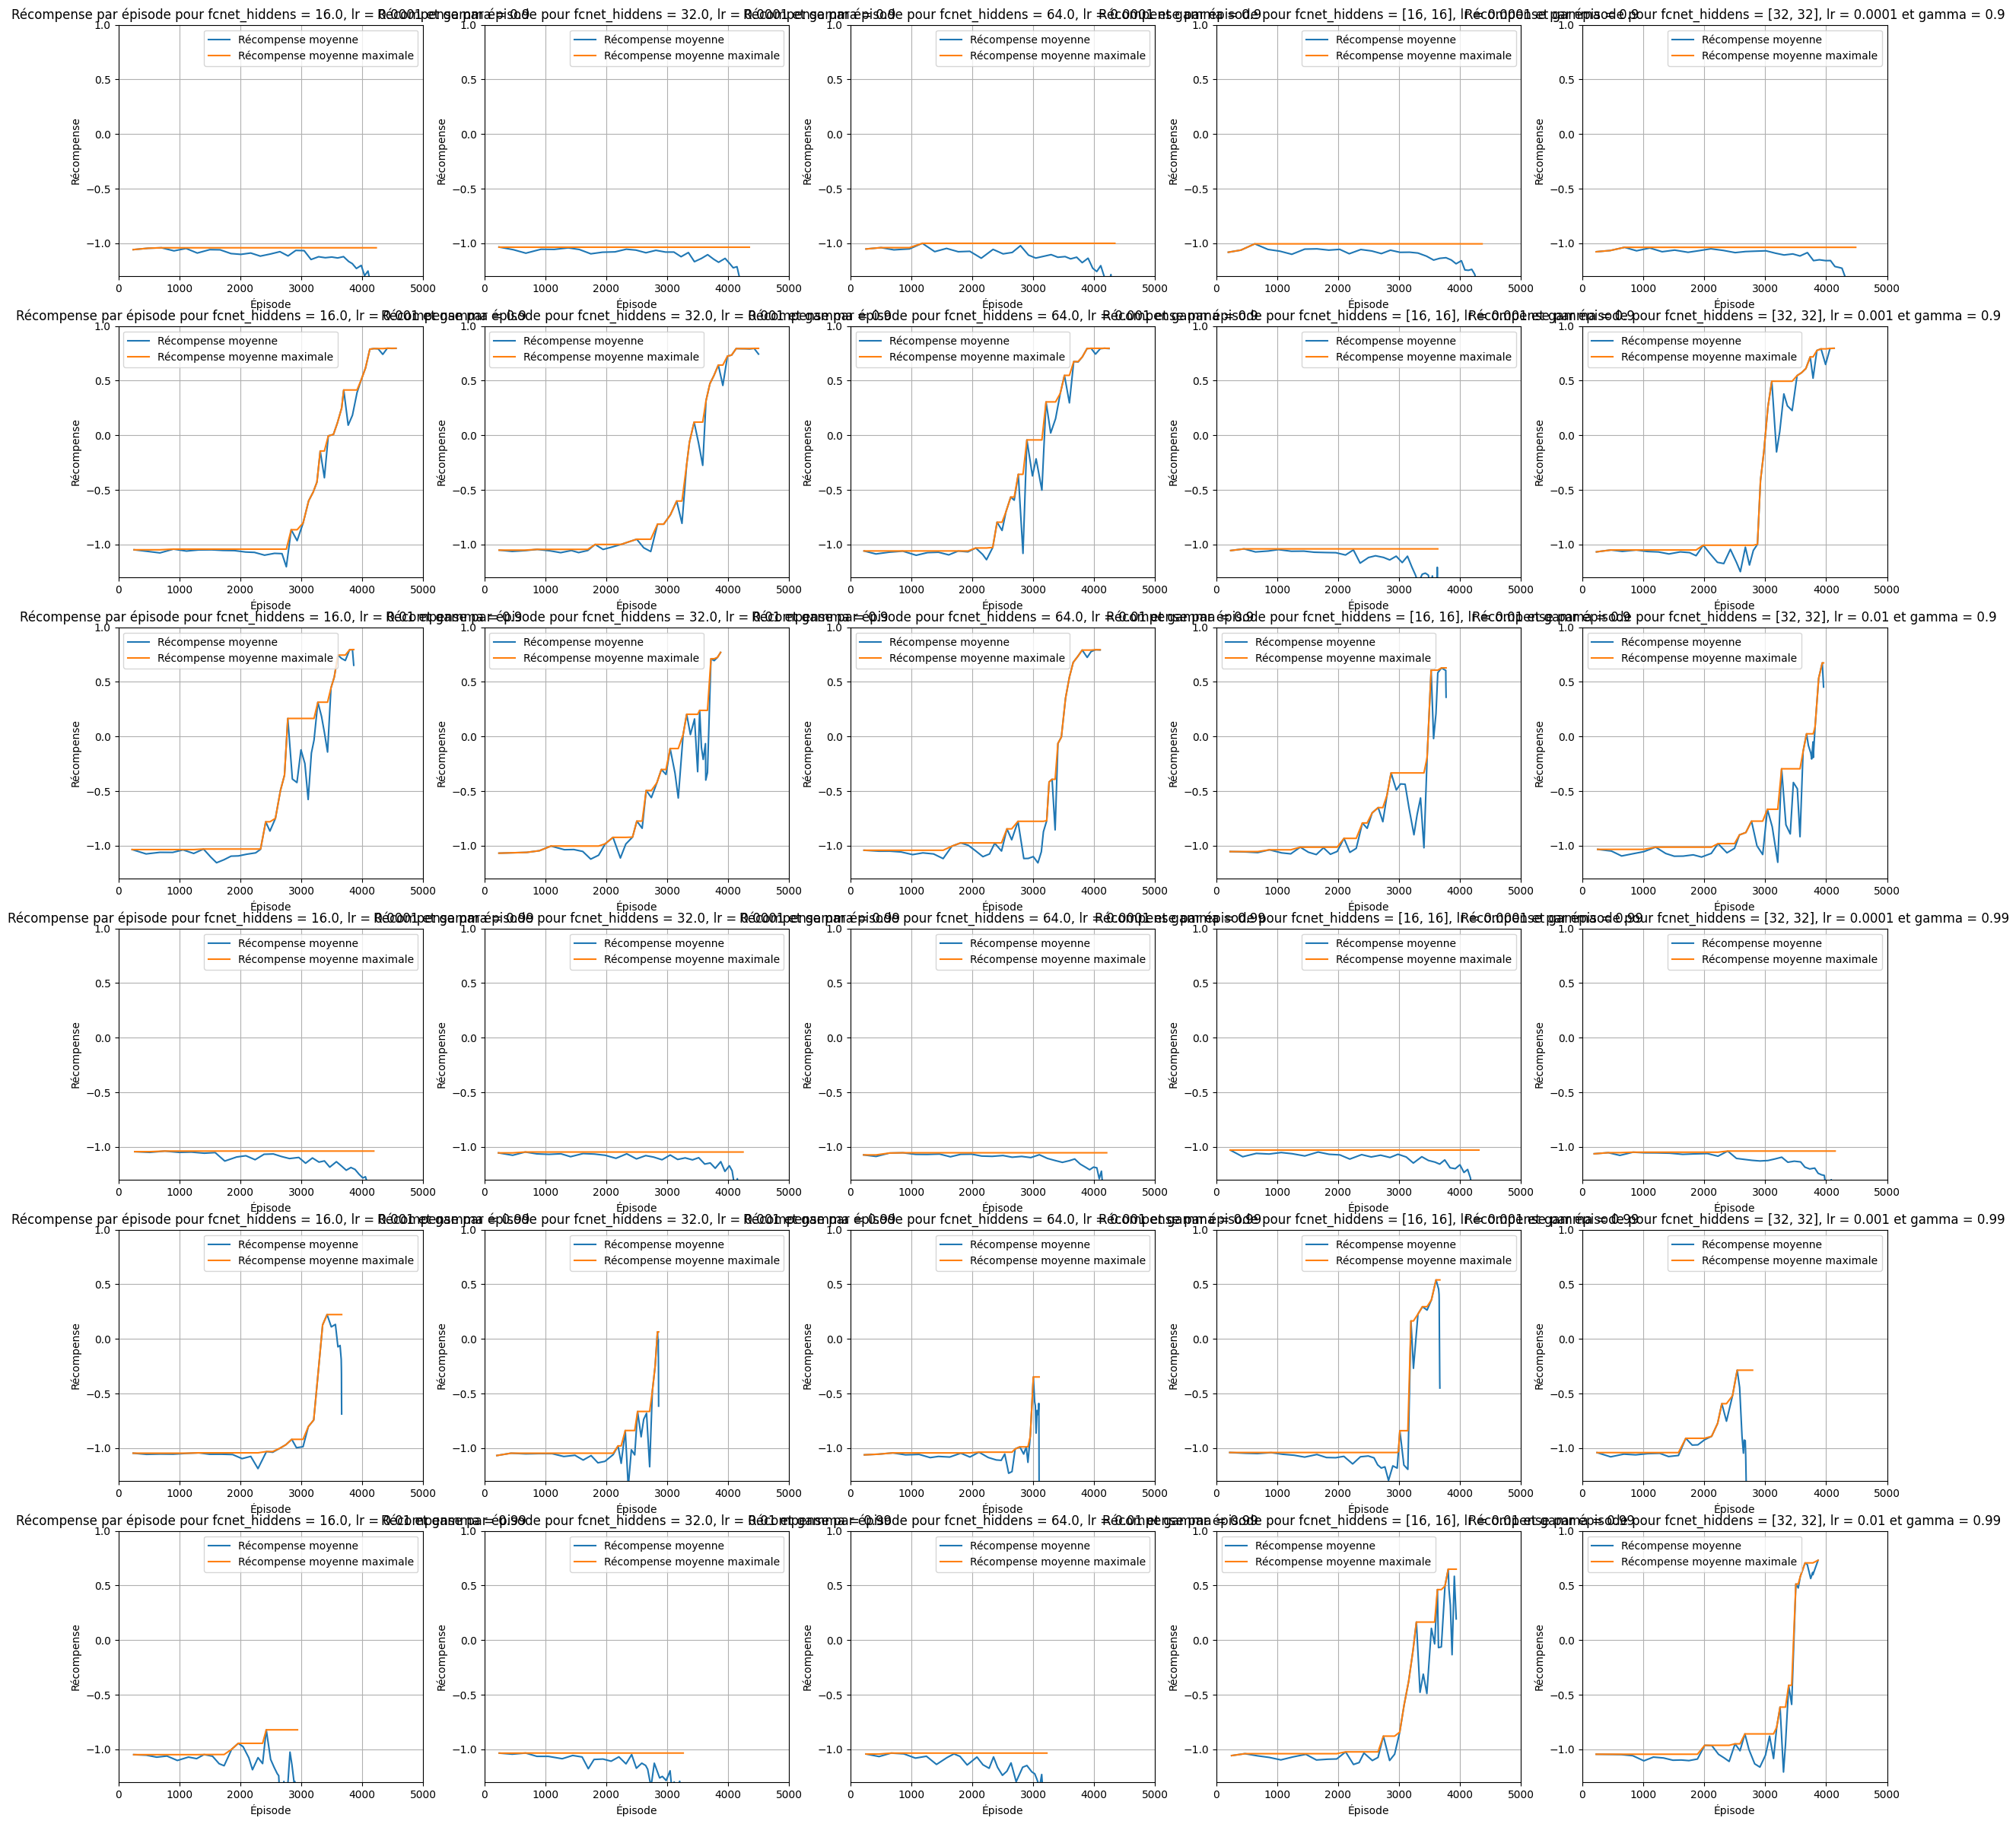

In [12]:
comparison_plot_3(results,
                  "fcnet_hiddens", [16., 32., 64., [16, 16], [32, 32]],
                  "lr", [0.0001, 0.001, 0.01],
                  "gamma", [0.9, 0.99],
                  0, 5000,
                  -1.3, 1
                 )

Meilleur résultat pour :

- Architecture de [64]
- lr de 0.01
- gamma de 0.9

# DQN pour environnement 4

In [18]:
ray.shutdown()

In [6]:
config = (
    DQNConfig()
    .environment(
        FrozenLake4Env,
        env_config = {'lake_map' : generate_random_map(8)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [35000, 0.01]]
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : tune.grid_search([[16], [32], [64], [16, 16], [32, 32]])
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": 40000},
    ),
)
results = tuner.fit()

2025-06-18 18:55:18,824	WARNING algorithm_config.py:4766 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=5815) 2025-06-18 18:55:22,687	WARNING algorithm_config.py:4766 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(SingleAgentEnvRunner pid=5878) 2025-06-18 18:55:28,489	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been de

(DQN pid=7185) Install gputil for GPU system monitoring.
(DQN(env=<class '__main__.FrozenLake4Env'>; env-runners=3; learners=0; multi-agent=False) pid=7185) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/thewalder/ray_results/DQN_2025-06-18_18-55-15/DQN_FrozenLake4Env_03ca1_00004_4_fcnet_hiddens=32_32,gamma=0.9000,lr=0.0010_2025-06-18_18-55-18/checkpoint_000000)
(DQN pid=7185) 2025-06-18 19:00:42,985	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future! [repeated 2x across cluster]
(DQN pid=7399) 2025-06-18 19:01:53,969	WARNING algorithm_config.py:4766 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=Fal

(SingleAgentEnvRunner pid=8678) 2025-06-18 19:07:10,633	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(SingleAgentEnvRunner pid=8679) 2025-06-18 19:07:10,610	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(DQN pid=8639) Install gputil for GPU system monitoring.
(DQN(env=<class '__main__.FrozenLake4Env'>; env-runners=3; learners=0; multi-agent=False) pid=8639) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/thewalder/ray_results/DQN_2025-06-18_18-55-15/DQN_FrozenLake4Env_03ca1_00009_9_fcnet_hiddens=32_32,gamma=0.9900,lr=

(DQN pid=9713) 2025-06-18 19:13:23,223	WARNING algorithm_config.py:4766 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(SingleAgentEnvRunner pid=9752) 2025-06-18 19:13:28,154	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(DQN pid=9713) Install gputil for GPU system monitoring.
(DQN(env=<class '__main__.FrozenLake4Env'>; env-runners=3; learners=0; multi-agent=False) pid=9713) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/thewalder/ray

(SingleAgentEnvRunner pid=11030) 2025-06-18 19:19:54,883	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(SingleAgentEnvRunner pid=11031) 2025-06-18 19:19:55,000	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(DQN pid=10993) Install gputil for GPU system monitoring.
(DQN(env=<class '__main__.FrozenLake4Env'>; env-runners=3; learners=0; multi-agent=False) pid=10993) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/thewalder/ray_results/DQN_2025-06-18_18-55-15/DQN_FrozenLake4Env_03ca1_00019_19_fcnet_hiddens=32_32,gamma=0.990

...

(SingleAgentEnvRunner pid=36283) 2025-06-18 21:45:58,348	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(DQN pid=36247) Install gputil for GPU system monitoring.
(raylet) [2025-06-18 21:46:03,540 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.96014 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(DQN pid=36247) 2025-06-18 21:45:58,607	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future! [repeated 3x across cluster]
(raylet) [2025-06-18 21

(raylet) [2025-06-18 21:48:53,963 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.95097 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:49:03,991 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.95056 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:49:14,039 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.95031 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(DQN(env=<class '__main__.FrozenLakeEnv'>; env-runners=3; learners=0; multi-agent=False) pid=36659) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/thewalder/ray_results/DQN_2025-06-18_21-14-16/DQN_FrozenLakeEnv_6

(raylet) [2025-06-18 21:53:54,368 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94919 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:54:04,379 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94919 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:54:14,391 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94919 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:54:24,403 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94912 GB; capacity: 101.131 GB. Object creation will fail if spilling i

(raylet) [2025-06-18 21:59:14,748 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94877 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:59:24,759 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94871 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:59:34,772 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.9487 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 21:59:44,784 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.9487 GB; capacity: 101.131 GB. Object creation will fail if spilling is 

(raylet) [2025-06-18 22:04:35,116 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94809 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 22:04:45,127 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94809 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 22:04:55,139 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94809 GB; capacity: 101.131 GB. Object creation will fail if spilling is required.
(raylet) [2025-06-18 22:05:05,153 E 5579 5601] (raylet) file_system_monitor.cc:116: /tmp/ray/session_2025-06-18_18-55-15_556159_5432 is over 95% full, available space: 4.94809 GB; capacity: 101.131 GB. Object creation will fail if spilling i

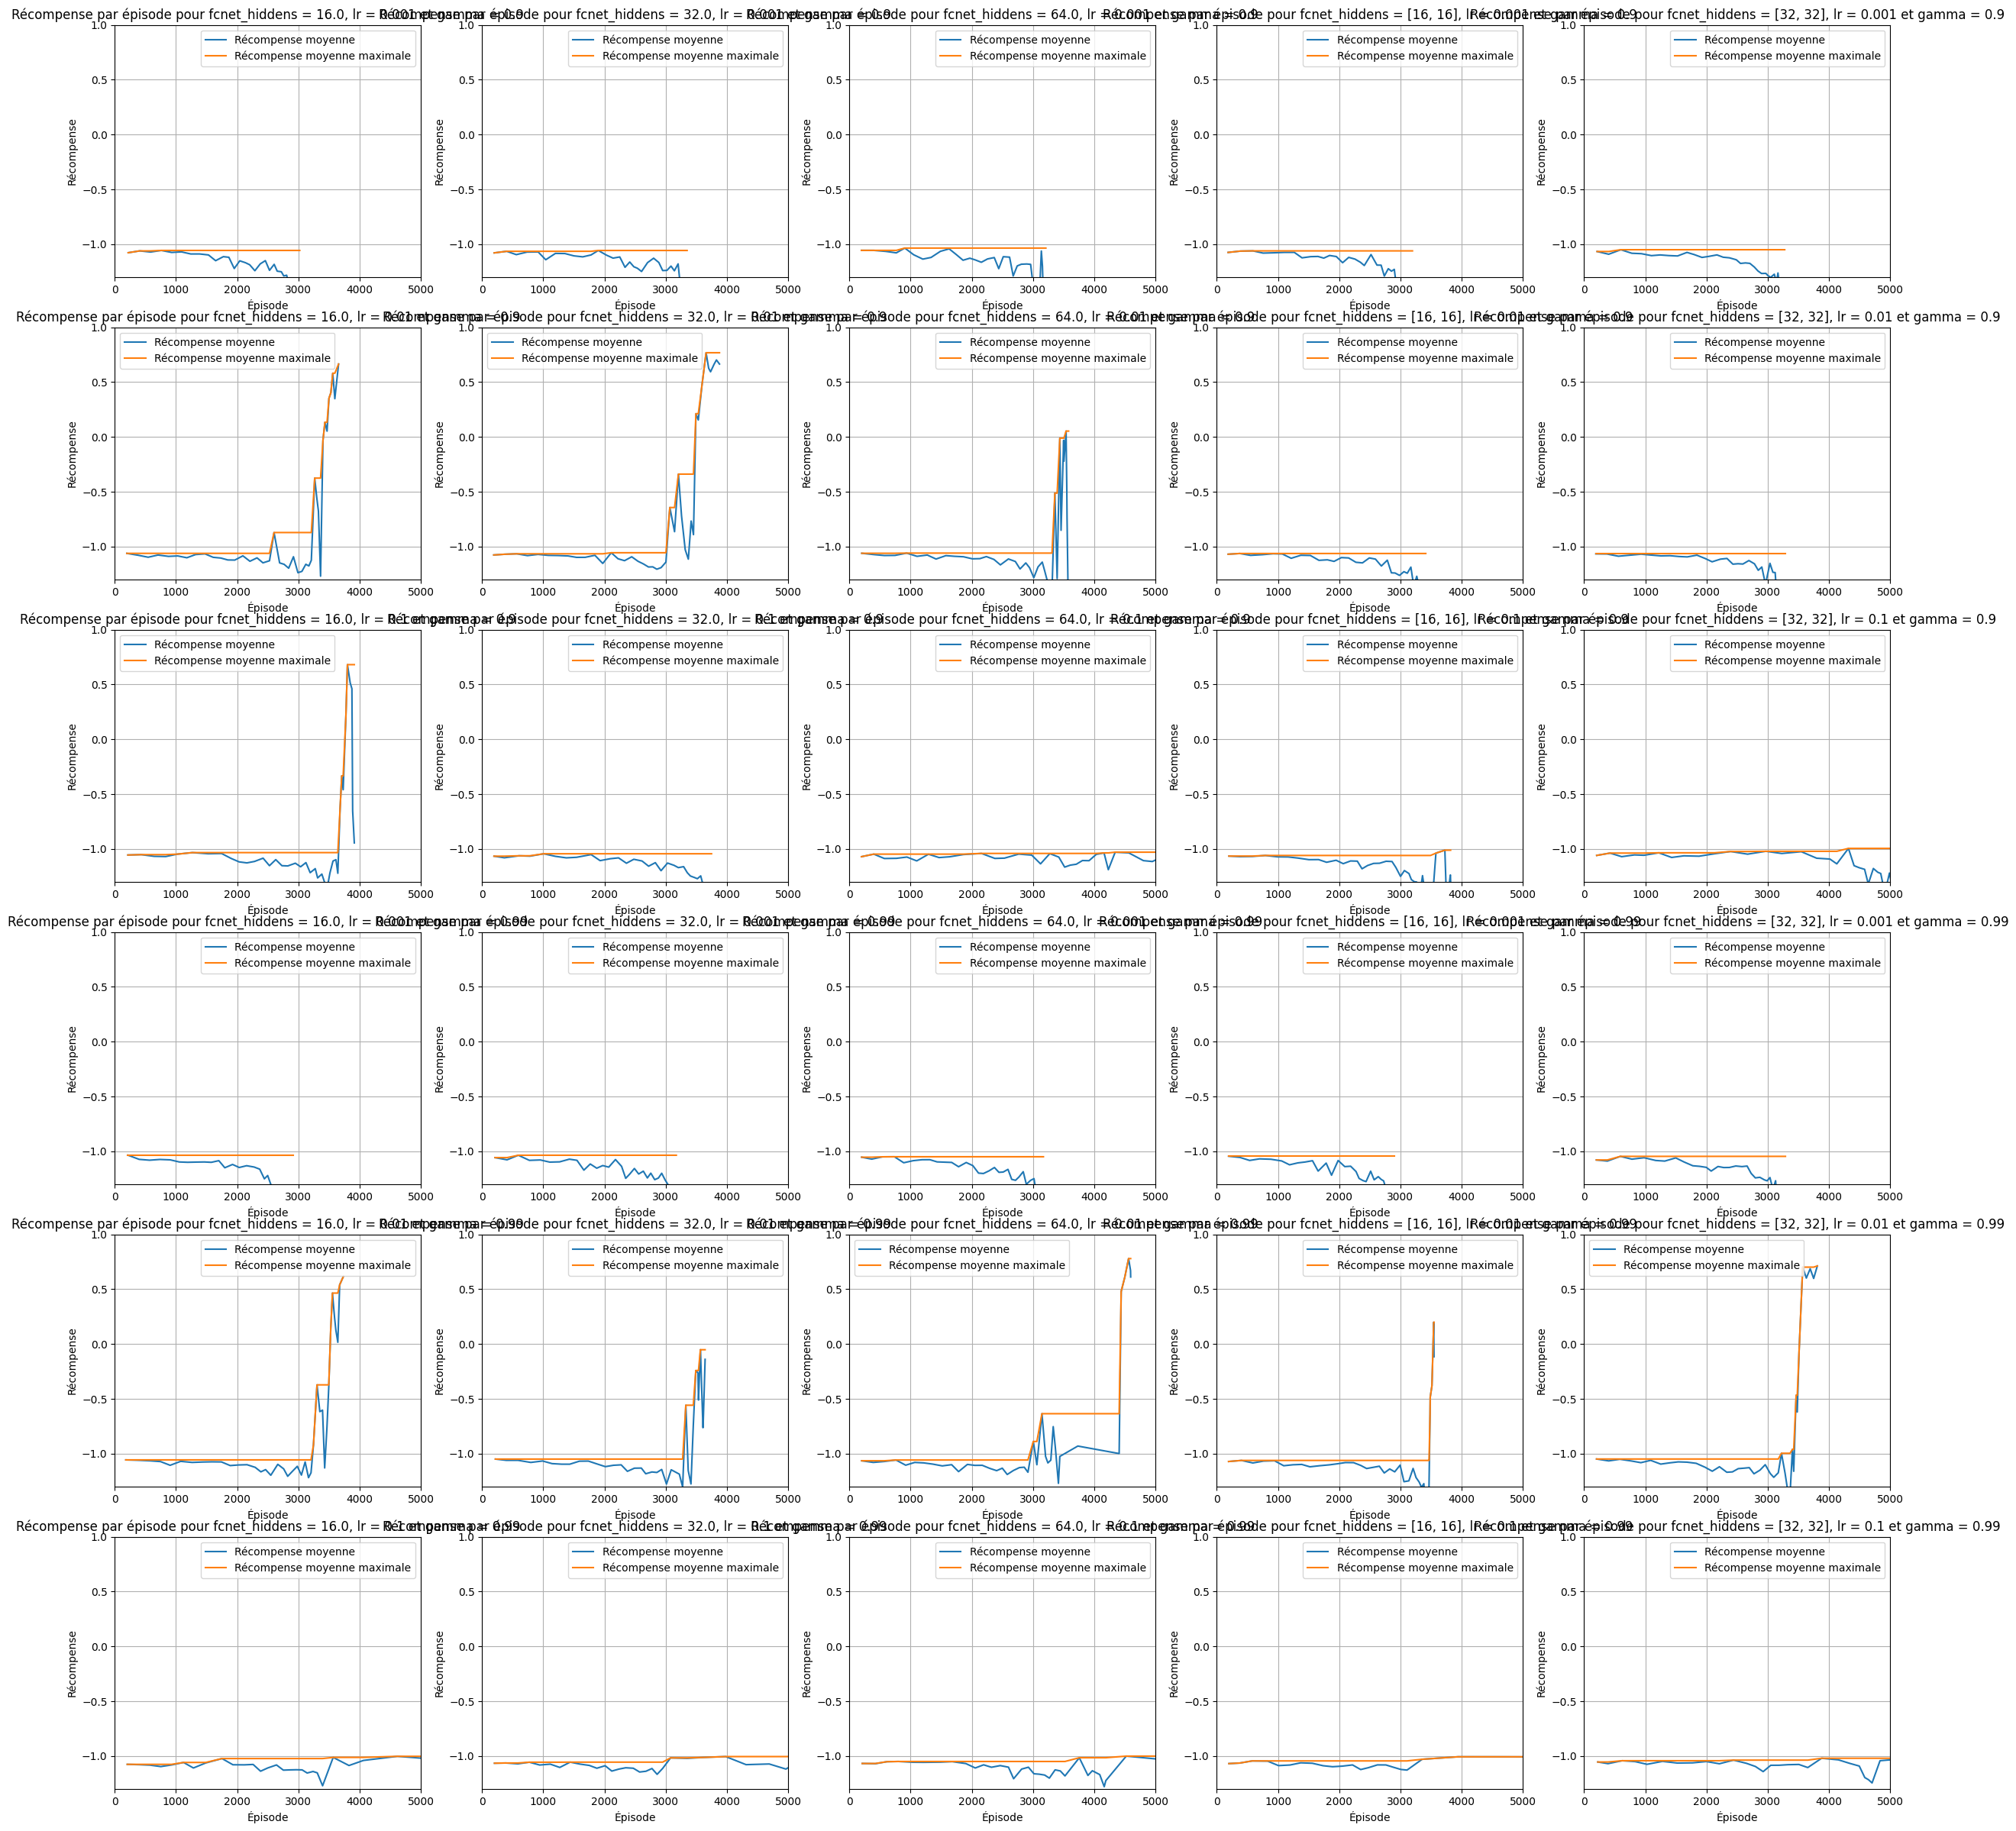

In [9]:
comparison_plot_3(results,
                  "fcnet_hiddens", [16., 32., 64., [16, 16], [32, 32]],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 5000,
                  -1.3, 1
                 )

Meilleur résultat pour :

- Architecture de [16]
- lr de 0.01
- gamma de 0.9

2025-06-23 10:40:44,031	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html


.HFF
FFHF
FFHH
FFFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

.FFFFF
FFFFFF
FFFFHF
FFHFFH
FFFFFF
FFFHFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

.FFFHFFF
FFFFFFFF
FHFFFFFF
FFFHFFFF
FFFHFFFH
FFFFFFFF
FFFFFFFF
FFFFFFFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

.FFFFFFFHF
FFFFFFFHFH
HFFFFFFFFF
HFFFFHFHFF
FFFFHHFFFF
FFFFHFFFFF
HHHHFHHFFF
HHHHFFFFFF
HFFFFFHFHF
FFHHFFHFFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

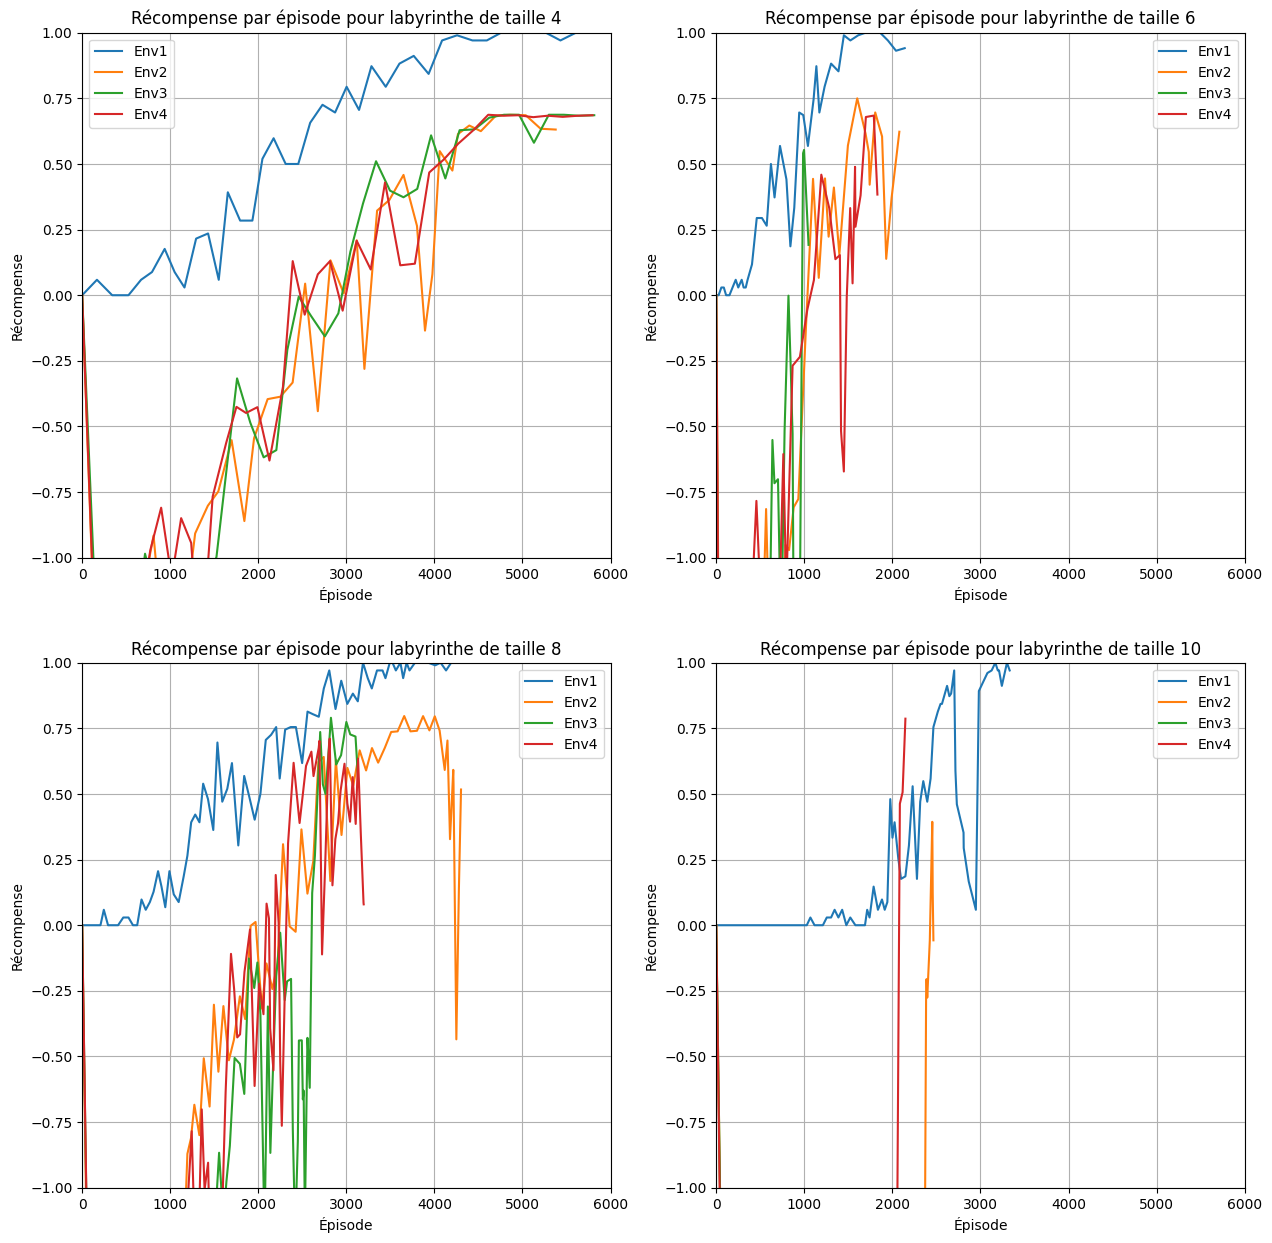

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
data = [(4, 0, 0, 40000), (6, 0, 1, 40000), (8, 1, 0, 80000), (10, 1, 1, 80000)]


for size, x, y, timesteps in data :

    lake_map = generate_random_map(size)
    env = FrozenLakeEnv({'lake_map' : lake_map})
    env.render()

    # First env
    
    config = (
        DQNConfig()
        .environment(
            FrozenLakeEnv,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
            num_env_runners=3,
            num_envs_per_env_runner = 10
        )
    
            .training(
            lr = 0.01,
            gamma = 0.9,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [32, 32]
            }
        )

    )

    algo = config.build_algo()
    ordonnees = [0]
    toPlot = [0]
    timesteps_done = 0
    while timesteps_done < timesteps :
        resu = algo.train()
        timesteps_done = resu['env_runners']['num_env_steps_sampled_lifetime']
        ordonnees.append(ordonnees[-1] + resu['env_runners']['num_episodes'])
        toPlot.append(resu['env_runners']['episode_return_mean'])
    axes[x, y].plot(ordonnees, toPlot, label = 'Env1')
    algo.stop()



    # Second env

    config = (
        DQNConfig()
        .environment(
            FrozenLake2Env,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
            num_env_runners=3,
            num_envs_per_env_runner = 10
        )
    
            .training(
            lr = 0.01,
            gamma = 0.9,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [32]
            }
        )

    )

    algo = config.build_algo()
    ordonnees = [0]
    toPlot = [0]
    timesteps_done = 0
    while timesteps_done < timesteps :
        resu = algo.train()
        timesteps_done = resu['env_runners']['num_env_steps_sampled_lifetime']
        ordonnees.append(ordonnees[-1] + resu['env_runners']['num_episodes'])
        toPlot.append(resu['env_runners']['episode_return_mean'])
    axes[x, y].plot(ordonnees, toPlot, label = 'Env2')
    algo.stop()


    # Troisième env

    config = (
        DQNConfig()
        .environment(
            FrozenLake2Env,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
            num_env_runners=3,
            num_envs_per_env_runner = 10
        )
    
            .training(
            lr = 0.01,
            gamma = 0.9,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [64]
            }
        )

    )

    algo = config.build_algo()
    ordonnees = [0]
    toPlot = [0]
    timesteps_done = 0
    while timesteps_done < timesteps :
        resu = algo.train()
        timesteps_done = resu['env_runners']['num_env_steps_sampled_lifetime']
        ordonnees.append(ordonnees[-1] + resu['env_runners']['num_episodes'])
        toPlot.append(resu['env_runners']['episode_return_mean'])
    axes[x, y].plot(ordonnees, toPlot, label = 'Env3')
    algo.stop()


    # env 4

    config = (
        DQNConfig()
        .environment(
            FrozenLake2Env,
            env_config = {'lake_map' : lake_map}
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
            num_env_runners=3,
            num_envs_per_env_runner = 10
        )
    
            .training(
            lr = 0.01,
            gamma = 0.9,
            epsilon = [[0, 1], [timesteps*0.8, 0.01]],
        )

        .callbacks(EvaluationCallback)

        
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [16]
            }
        )

    )

    algo = config.build_algo()
    ordonnees = [0]
    toPlot = [0]
    timesteps_done = 0
    while timesteps_done < timesteps :
        resu = algo.train()
        timesteps_done = resu['env_runners']['num_env_steps_sampled_lifetime']
        ordonnees.append(ordonnees[-1] + resu['env_runners']['num_episodes'])
        toPlot.append(resu['env_runners']['episode_return_mean'])
    axes[x, y].plot(ordonnees, toPlot, label = 'Env4')
    algo.stop()
    ray.shutdown()

    axes[x, y].legend()
    axes[x ,y].set_xlabel("Épisode")
    axes[x ,y].set_ylabel("Récompense")
    axes[x ,y].set_title(f"Récompense par épisode pour labyrinthe de taille {size}")
    axes[x ,y].grid()
    axes[x ,y].set_xlim([0, 6000])
    axes[x ,y].set_ylim([-1, 1])
plt.show()



On remarque que l'environnement 1 fonctionne mieux avec RLlib lorsque l'on fait usage du parallélisme.

## Poursuite entraînement DQN RLlib

In [8]:
steps = 80000

config = (
    DQNConfig()
    .environment(
        FrozenLakeEnv,
        env_config = {'lake_map' : generate_random_map(10)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = tune.grid_search([0.001, 0.01, 0.1]),
        gamma = tune.grid_search([0.9, 0.99]),
        epsilon = [[0, 1], [steps * 0.8, 0.01]],
        target_network_update_freq = tune.grid_search([100, 500, 1000])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : [32, 32]
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": steps},
    ),
)
results = tuner.fit()

(DQN pid=73280) 2025-06-23 11:20:39,726	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(SingleAgentEnvRunner pid=73391) 2025-06-23 11:20:44,112	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been deprecated. Use `RLModule(observation_space=.., action_space=.., inference_only=.., model_config=.., catalog_class=..)` instead. This will raise an error in the future!
(DQN pid=73279) 2025-06-23 11:20:39,741	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_

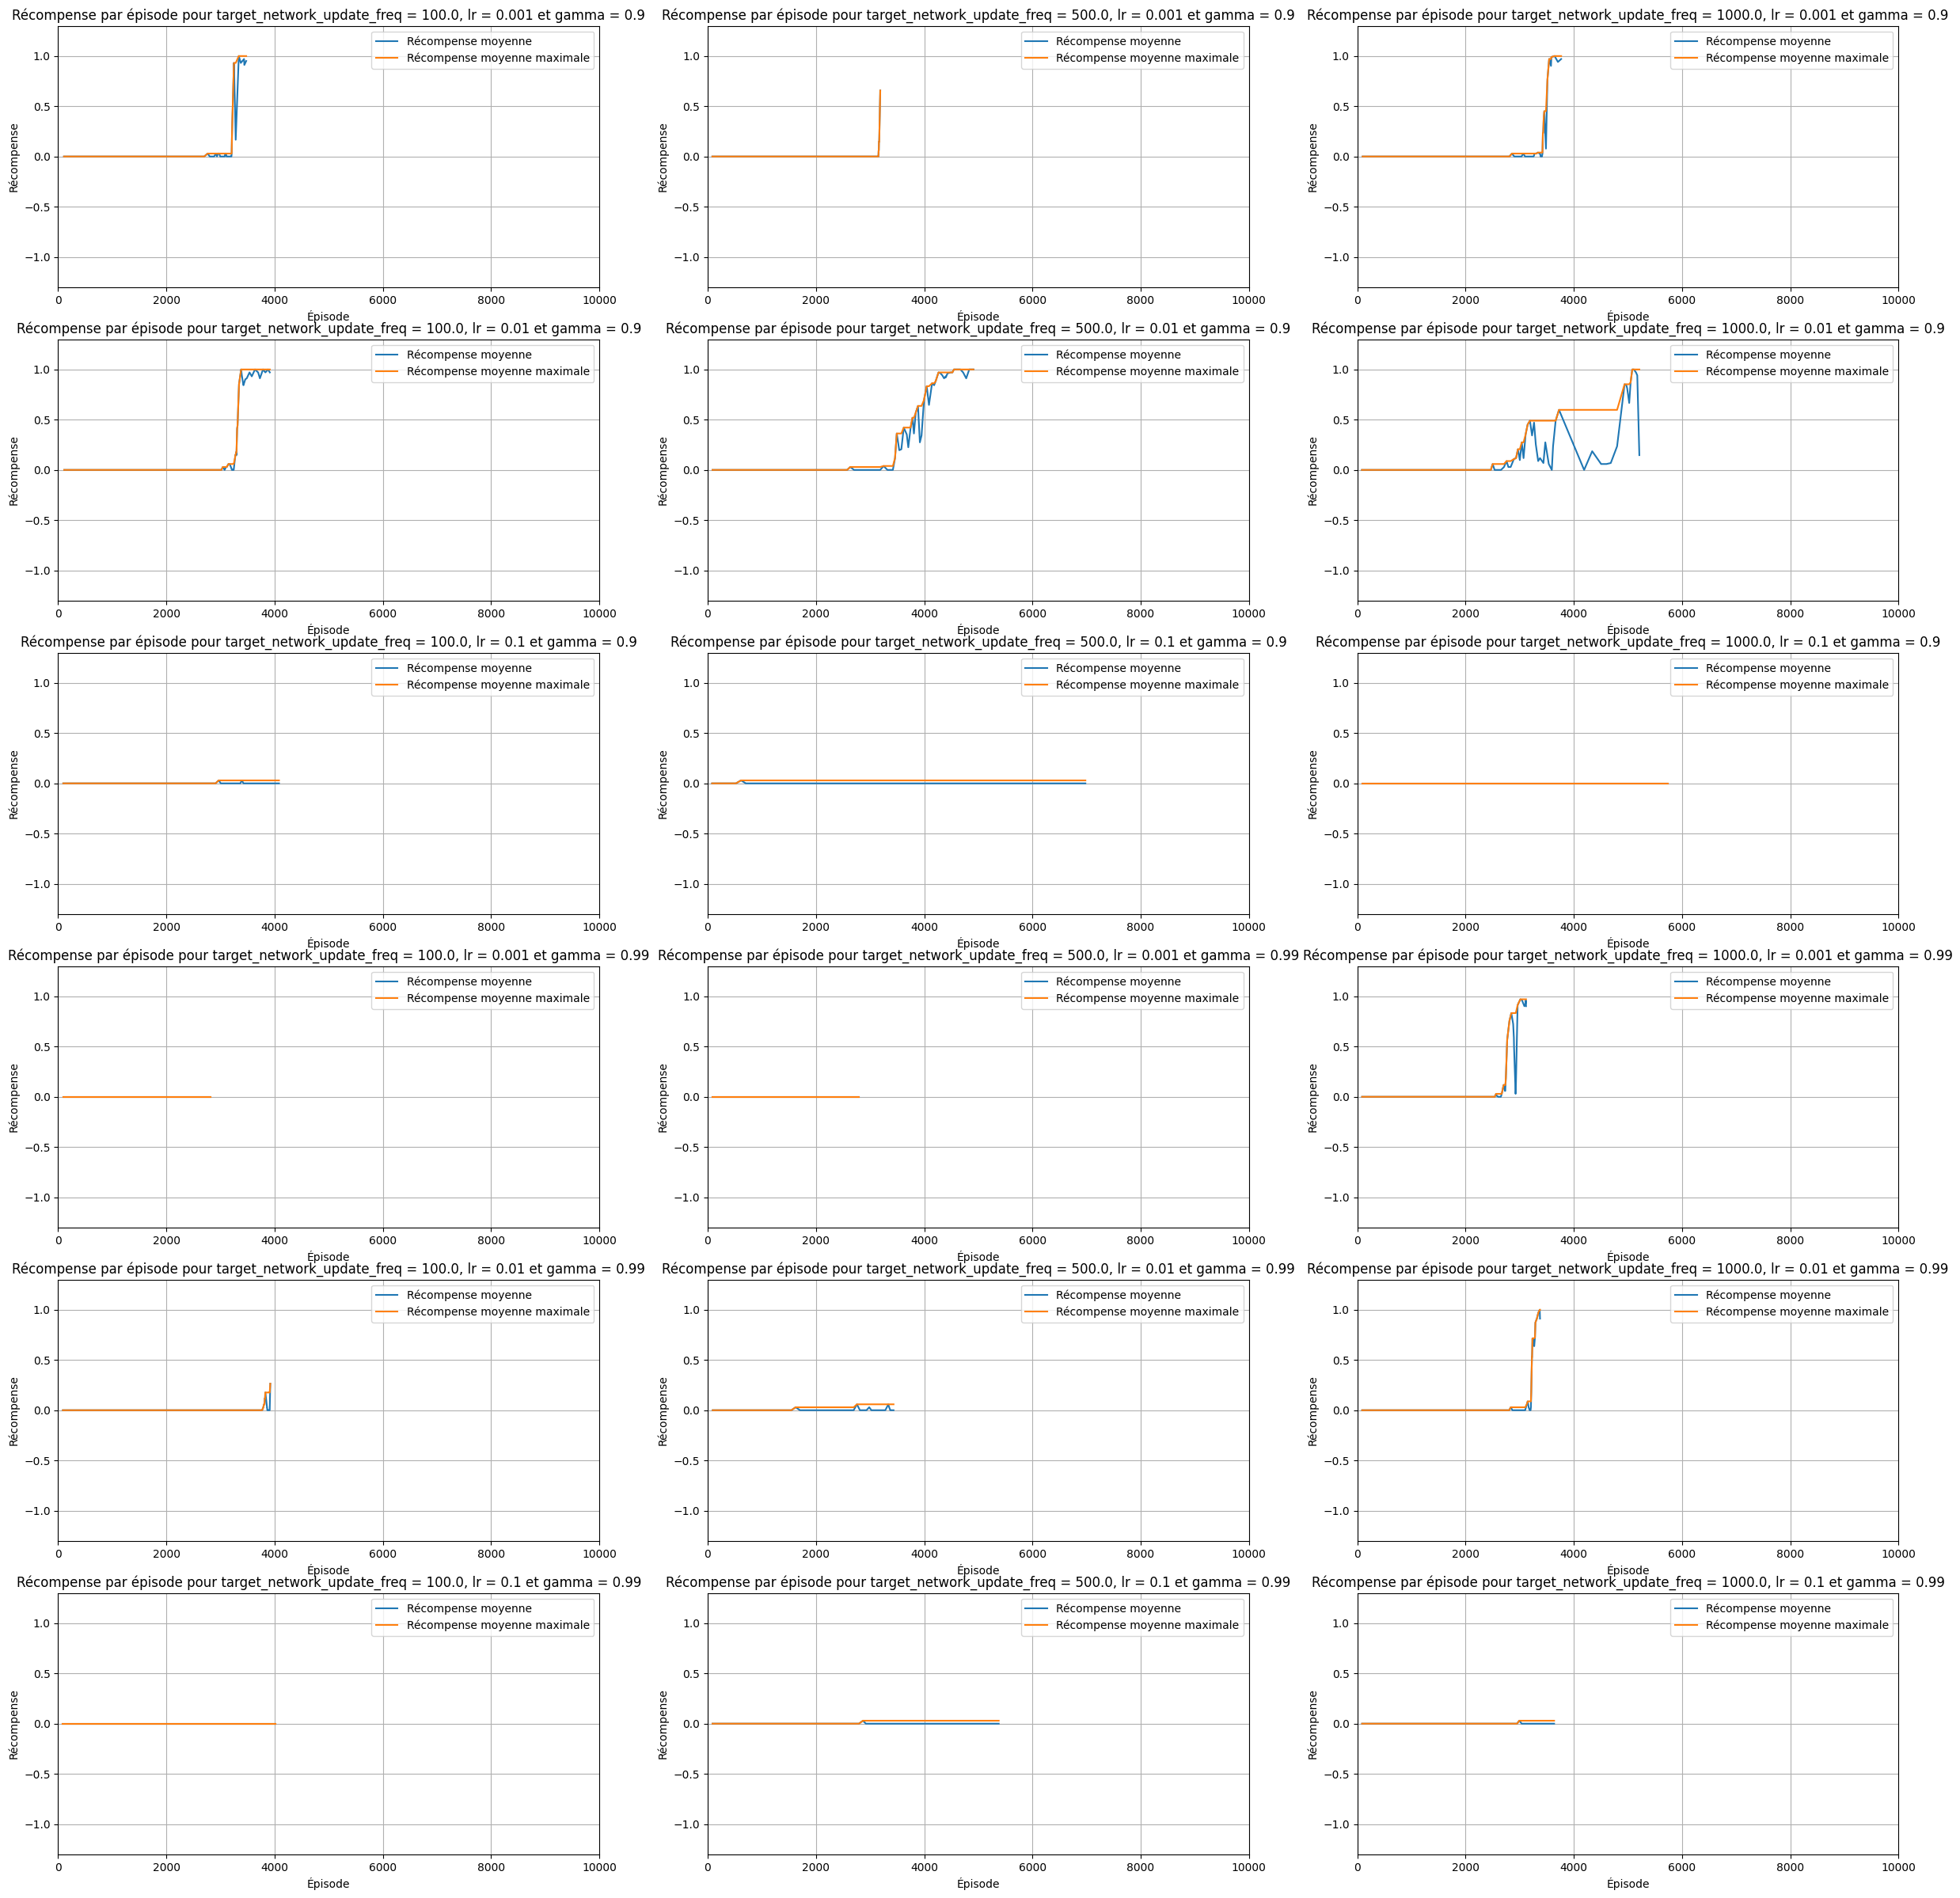

In [12]:
comparison_plot_3(results,
                  "target_network_update_freq", [100, 500, 1000],
                  "lr", [0.001, 0.01, 0.1],
                  "gamma", [0.9, 0.99],
                  0, 10000,
                  -1.3, 1.3
                 )

On conserve les même paramètres pour l'env1 avec
- target_network_update_freq : 500

Essayons d'être plus précis sur la valeur de ce paramètre.

In [13]:
steps = 80000

config = (
    DQNConfig()
    .environment(
        FrozenLakeEnv,
        env_config = {'lake_map' : generate_random_map(10)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = 0.01,
        gamma = 0.9,
        epsilon = [[0, 1], [steps * 0.8, 0.01]],
        target_network_update_freq = tune.grid_search([250, 500, 750]),
        replay_buffer_config = {
            'capacity' : tune.grid_search([10000, 30000, 50000])
        }
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : [32, 32]
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": steps},
    ),
)
results = tuner.fit()

2025-06-23 11:49:31,388	ERROR tune_controller.py:1331 -- Trial task failed for trial DQN_FrozenLakeEnv_1baa9_00000
Traceback (most recent call last):
  File "/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 21, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 103, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/_private/worker.py", line 2822, in get
    values, debugger_breakpoint = worker.get_objects(object_refs, timeout=timeout)
                                  ^^^^^^^^^^

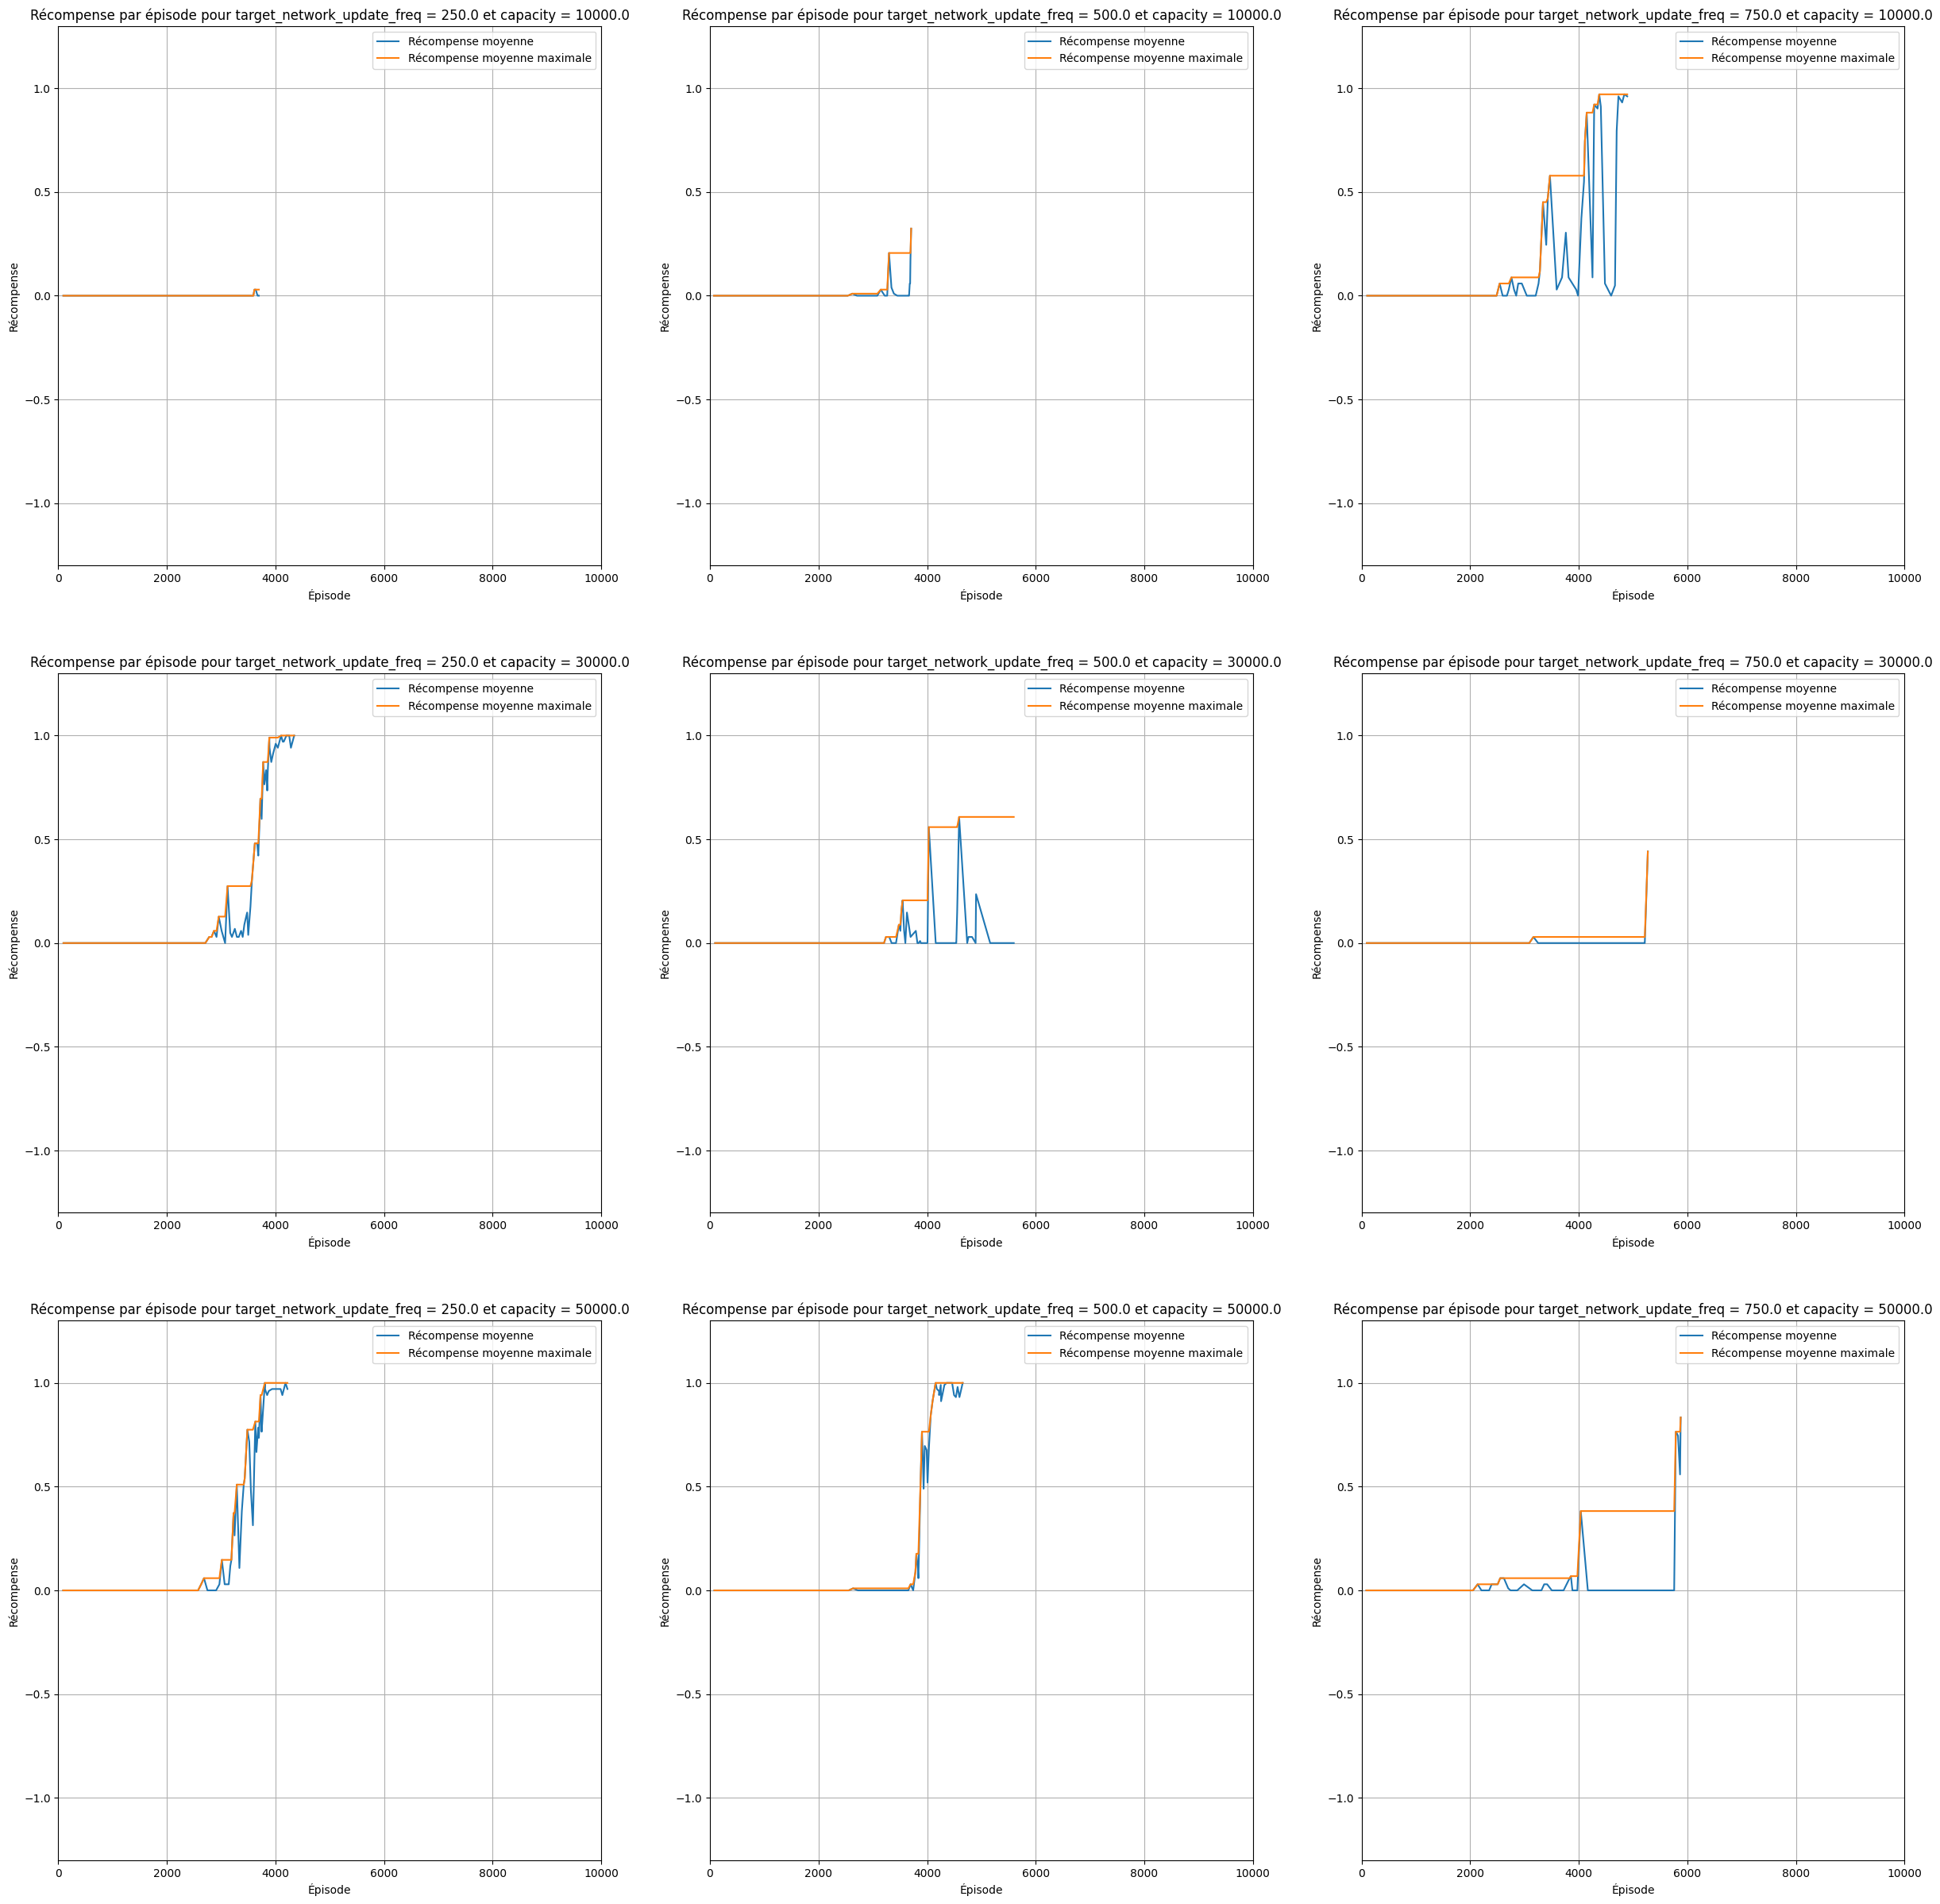

In [15]:
comparison_plot_2(results,
                  "target_network_update_freq", [250, 500, 750],
                  "capacity", [10000, 30000, 50000],
                  0, 10000,
                  -1.3, 1.3
                 )

On préserve :
- target_network_update_freq : 250
- buffer capacity : 50000

In [16]:
steps = 80000

config = (
    DQNConfig()
    .environment(
        FrozenLakeEnv,
        env_config = {'lake_map' : generate_random_map(10)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = 0.01,
        gamma = 0.9,
        epsilon = [[0, 1], [steps * 0.8, 0.01]],
        target_network_update_freq = tune.grid_search([100, 250, 400]),
        replay_buffer_config = {
            'capacity' : tune.grid_search([30000, 50000, 80000])
        },
        train_batch_size_per_learner = tune.grid_search([32, 64, 128, 256])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : [32, 32]
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": steps},
    ),
)
results = tuner.fit()

2025-06-23 12:58:56,536	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/home/enzo/ray_results/DQN_2025-06-23_12-02-31' in 0.1370s.
2025-06-23 12:58:56,835	INFO tune.py:1041 -- Total run time: 3384.88 seconds (3384.44 seconds for the tuning loop).


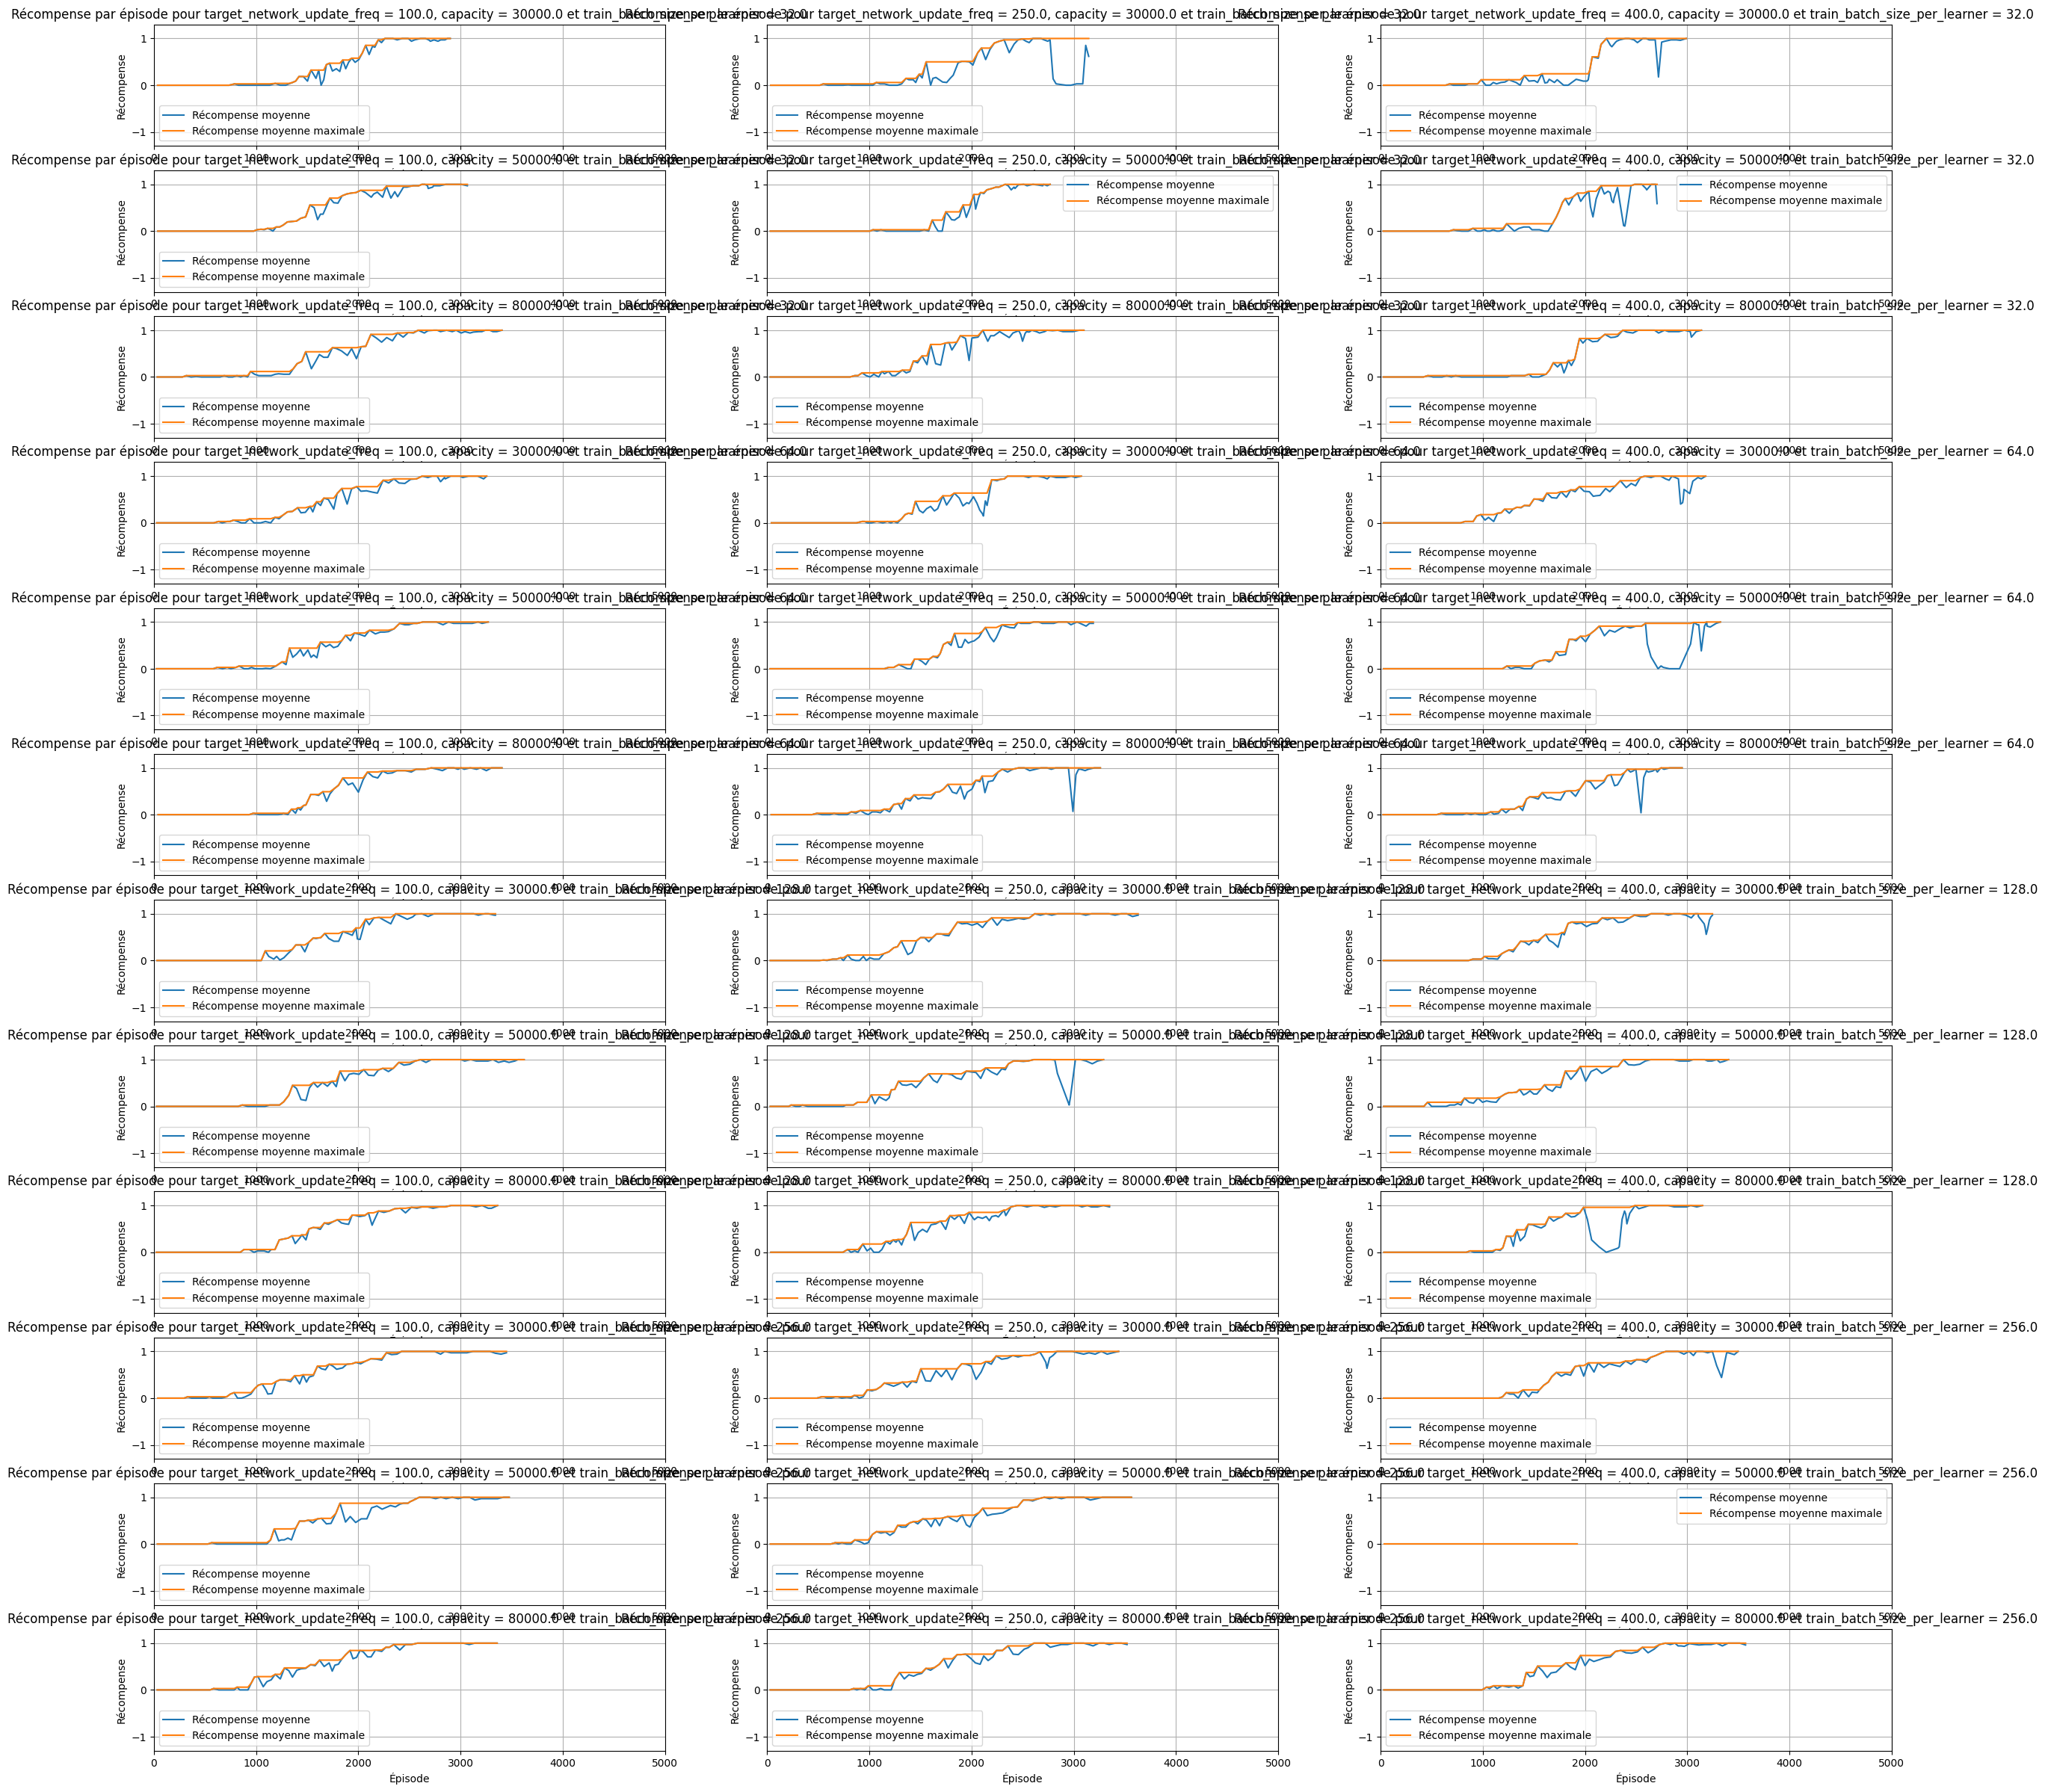

In [18]:
comparison_plot_3(results,
                  "target_network_update_freq", [100, 250, 400],
                  "capacity", [30000, 50000, 80000],
                  'train_batch_size_per_learner', [32, 64, 128, 256],
                  0, 5000,
                  -1.3, 1.3
                 )

On préserve :
- target_network_update_freq : 100
- buffer capacity : 30000
- train_batch_size_per_learner : 128

In [7]:
steps = 80000

config = (
    DQNConfig()
    .environment(
        FrozenLake3Env,
        env_config = {'lake_map' : generate_random_map(10)},
    )
    
    .env_runners(
        env_to_module_connector=lambda env: FlattenObservations(),
        num_env_runners=3,
        num_envs_per_env_runner = 10
    )


    .training(
        lr = 0.01,
        gamma = 0.9,
        epsilon = [[0, 1], [steps * 0.8, 0.01]],
        target_network_update_freq = tune.grid_search([100, 250, 400]),
        replay_buffer_config = {
            'capacity' : tune.grid_search([30000, 50000, 80000])
        },
        train_batch_size_per_learner = tune.grid_search([32, 64, 128, 256])
    )

    .rl_module(
        model_config = {
            "fcnet_hiddens" : [32, 32]
        }
    )
)



tuner = tune.Tuner(
    config.algo_class,
    param_space=config,
    run_config=train.RunConfig(
        stop={"num_env_steps_sampled_lifetime": steps},
    ),
)
results = tuner.fit()

2025-06-23 15:15:47,016	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(DQN pid=6827) 2025-06-23 15:15:50,294	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
(SingleAgentEnvRunner pid=6944) 2025-06-23 15:15:54,550	WARNING deprecation.py:50 -- DeprecationWarning: `RLModule(config=[RLModuleConfig object])` has been de

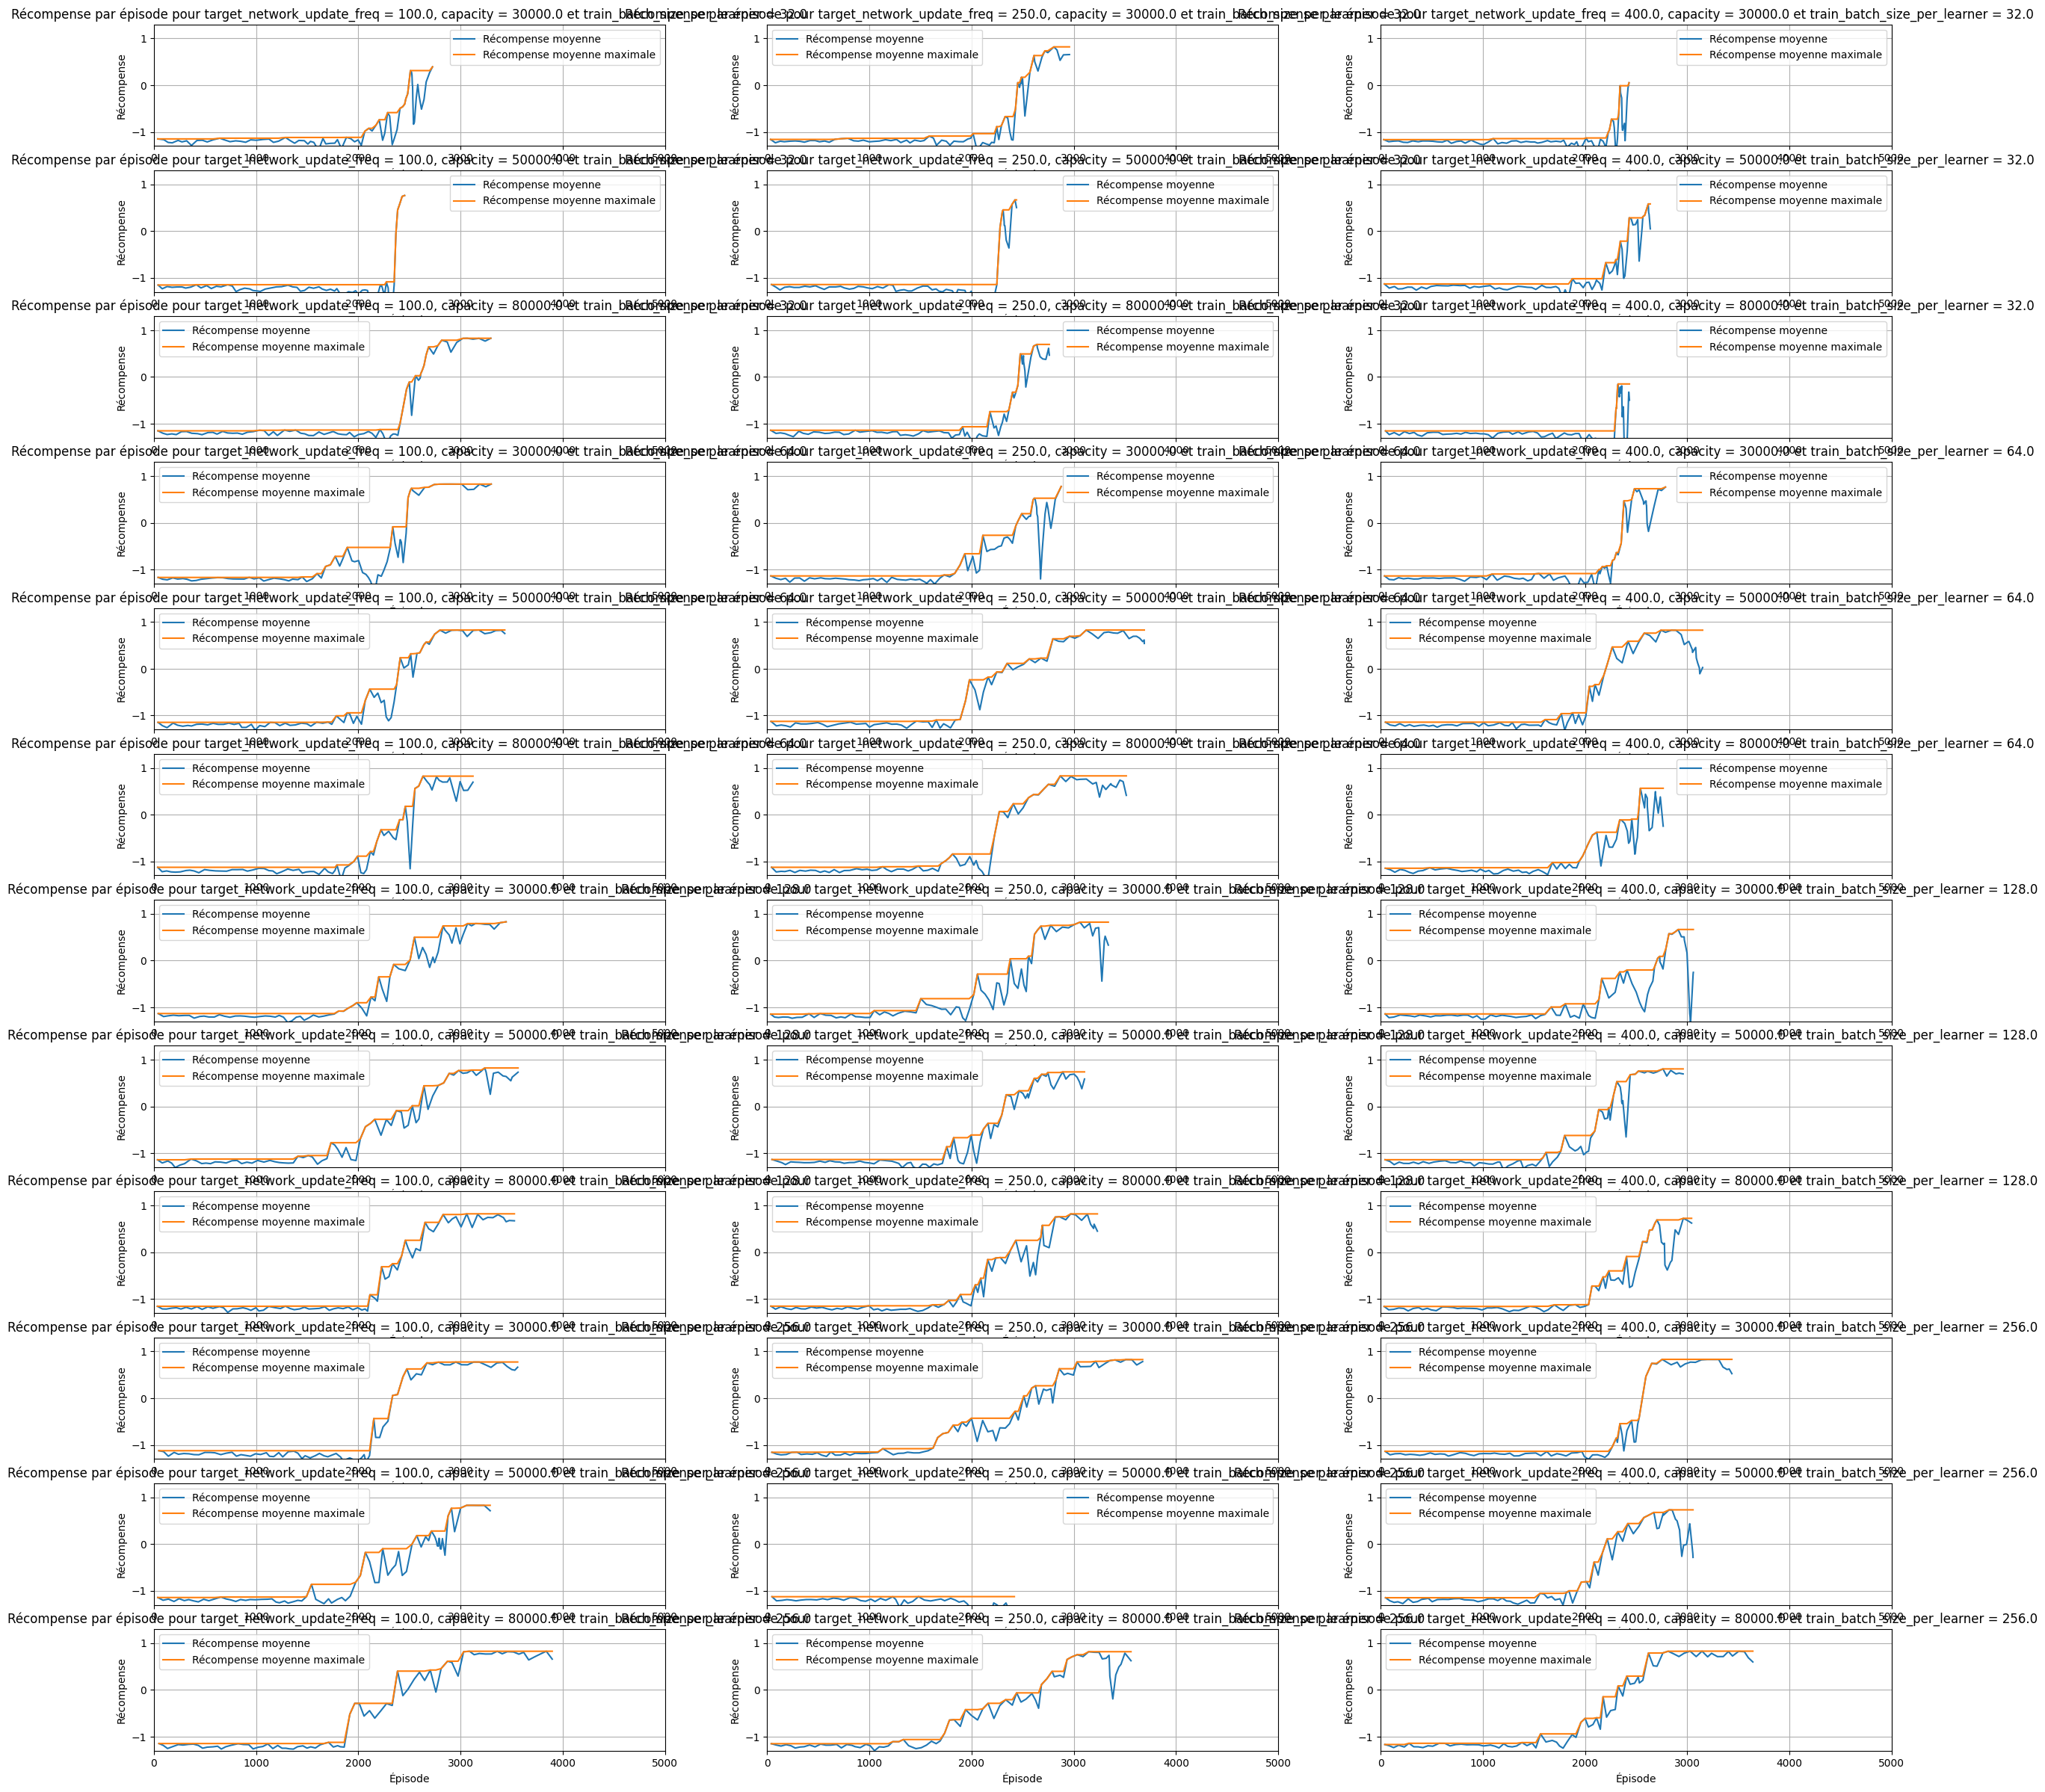

In [8]:
comparison_plot_3(results,
                  "target_network_update_freq", [100, 250, 400],
                  "capacity", [30000, 50000, 80000],
                  'train_batch_size_per_learner', [32, 64, 128, 256],
                  0, 5000,
                  -1.3, 1.3
                 )

On préserve :
- target_network_update_freq : 100
- buffer capacity : 30000
- train_batch_size_per_learner : 256

Mais de meilleurs résultats sont obtenus avec l'environnement 1

# Comparaison TODO

.FHH
FFFF
HFFF
FHFG



2025-06-24 13:11:02,743	WARNING algorithm_config.py:4968 -- You are running DQN on the new API stack! This is the new default behavior for this algorithm. If you don't want to use the new API stack, set `config.api_stack(enable_rl_module_and_learner=False,enable_env_runner_and_connector_v2=False)`. For a detailed migration guide, see here: https://docs.ray.io/en/master/rllib/new-api-stack-migration-guide.html
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You coul

.HFHFF
FFFHFF
HFFFFF
FFFFFF
FHFHFH
FFFFFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

.FFFFFFF
FFFFFFFF
FFFFFHFH
HHFHFHFF
FFFFFFFH
FHFFHFFF
FFHFFFFH
FHHFFFFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

.FFFFFFFHF
HFFFFFFFFF
HFFFFFFHFF
FFHFFFHFFF
FFHFHHFFHF
FHFFFFFFFH
FFFFHHFFFF
FHFHFFFFFF
FFFFFFFHFF
FHHHFFFHFG



/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/rllib/algorithms/algorithm.py:521: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  return UnifiedLogger(config, logdir, loggers=None)
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/enzo/Documents/Depots/customEnv/lib/python3.12/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: T

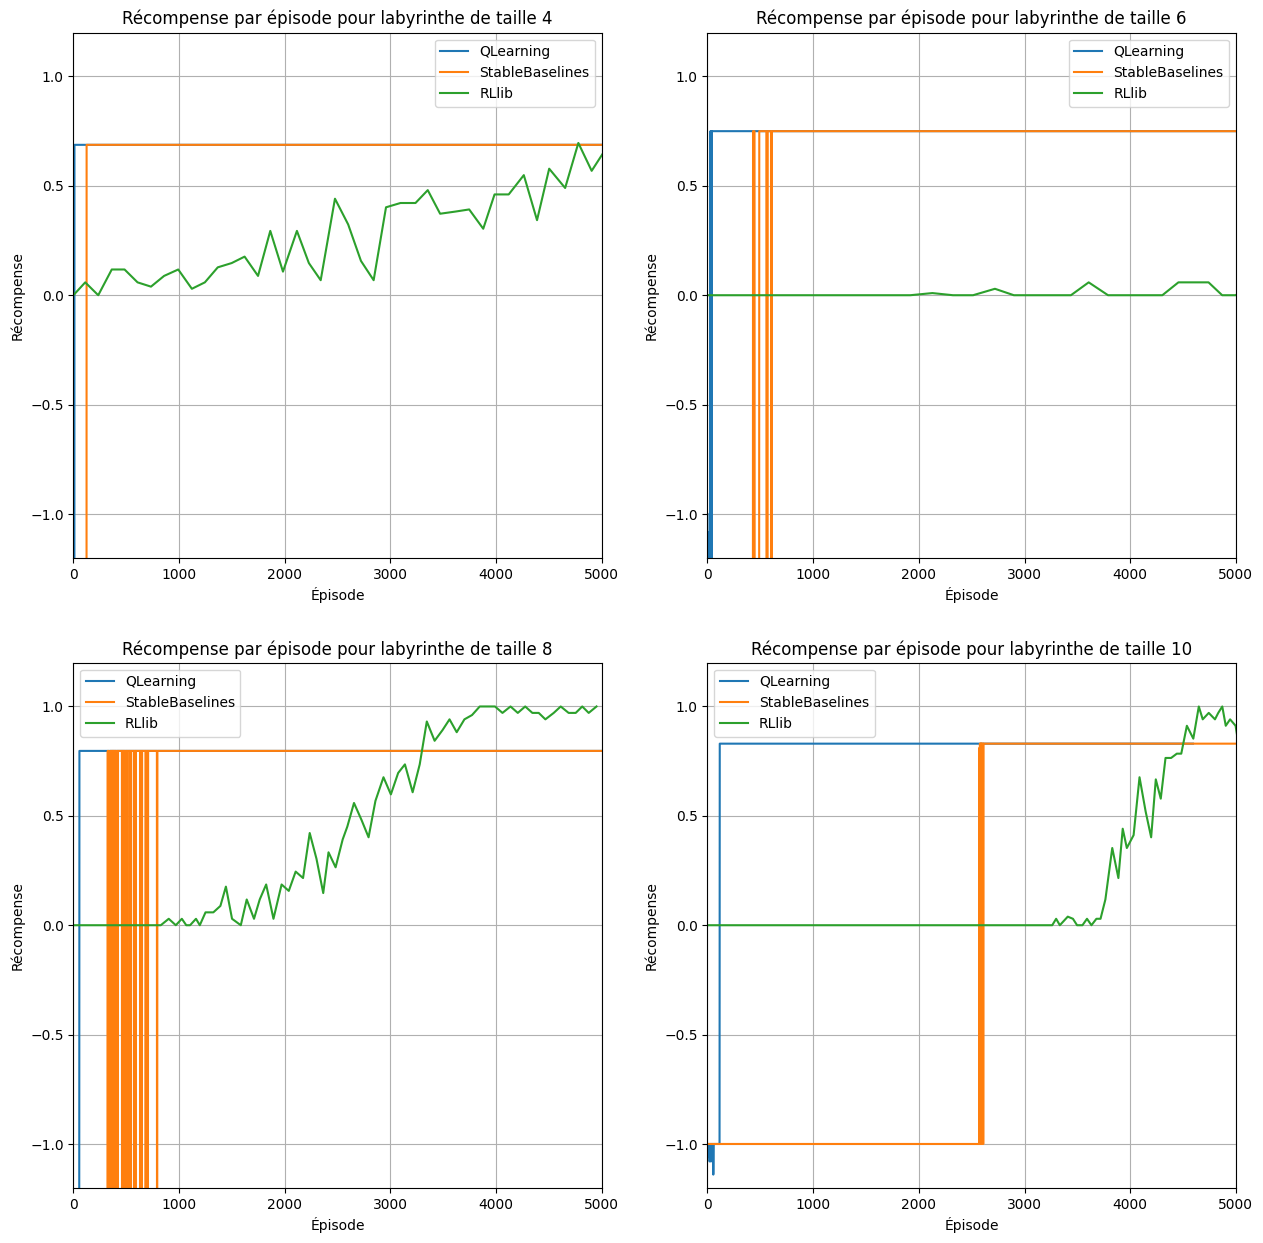

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
data = [(4, 0, 0, 80000, ([32])), (6, 0, 1, 80000, ([32])), 
        (8, 1, 0, 80000, ([32])), (10, 1, 1, 80000, ([32, 32]))]

for size, x, y, timesteps, (net_arch) in data :
    carte = generate_random_map(size)
    env = FrozenLake3Env({'lake_map' : carte})
    env.render()


    envQLearning = FrozenLake2Env({'lake_map' : carte})



    QTableOpti, QRewards, QprodRewards = train_q_learning(envQLearning, timesteps = timesteps, eps_start = 0.05, eps_end = 0.05, alpha = 1, gamma = 0.99, useProdForReward = True)


    axes[x ,y].plot(QprodRewards, label = 'QLearning')

    
    
    DQNmodel, DQNrewards, DQNprodRewards = train_dqn(env, exploration_initial_eps = 1, batch_size = 1000, buffer_size = 10000,
              exploration_fraction = 0.5, exploration_final_eps = 0.05, learning_rate = 0.0001, update_freq = 50, gamma = 0.9, 
                                                           net_arch = net_arch,
              timesteps = timesteps, useProdForReward = True)
    
    
    axes[x ,y].plot(DQNprodRewards, label = 'StableBaselines')



    # Configure the algorithm.
    config = (
        DQNConfig()
        .environment(
            FrozenLakeEnv,
            env_config = {'lake_map' : carte},
        )
        
        .env_runners(
            env_to_module_connector=lambda env: FlattenObservations(),
            num_env_runners=3,
            num_envs_per_env_runner = 10
        )
    
    
        .training(
            lr = 0.01,
            gamma = 0.9,
            epsilon = [[0, 1], [timesteps * 0.8, 0.01]],
            target_network_update_freq = 100,
            replay_buffer_config = {
                'capacity' : 30000
            },
            train_batch_size_per_learner = 128
        )
    
        .rl_module(
            model_config = {
                "fcnet_hiddens" : [32, 32]
            }
        )
    )

    algo = config.build_algo()
    ordonnees = [0]
    toPlot = [0]
    timesteps_done = 0
    while timesteps_done < timesteps :
        resu = algo.train()
        timesteps_done = resu['env_runners']['num_env_steps_sampled_lifetime']
        if 'episode_return_mean' in resu['env_runners'] :
            ordonnees.append(ordonnees[-1] + resu['env_runners']['num_episodes'])
            toPlot.append(resu['env_runners']['episode_return_mean'])
    axes[x, y].plot(ordonnees, toPlot, label = 'RLlib')
    algo.stop()
    ray.shutdown()

    axes[x, y].legend()
    axes[x ,y].set_xlabel("Épisode")
    axes[x ,y].set_ylabel("Récompense")
    axes[x ,y].set_title(f"Récompense par épisode pour labyrinthe de taille {size}")
    axes[x ,y].grid()
    axes[x ,y].set_xlim([0, 5000])
    axes[x ,y].set_ylim([-1.2, 1.2])
plt.show()